# Quantum Teleportation Robustness of Bell-Entangled Channels, with Linear ZNE
## Combined Simulation Notebook (Stages 1-4)

**Contents**
1. Setup: shared physics helpers, backends, and a single publication-quality plotting style used throughout
2. Stage 1 -- Ideal (noise-free) teleportation baseline, all four Bell states
3. Stage 2 -- Fidelity under four noise channels (bit-flip, phase-flip, depolarizing, amplitude-damping), Haar-averaged over n=150 random input states, with closed-form and QuTiP cross-checks
4. Stage 3 -- Routing-induced noise: natural vs. forced-SWAP qubit layout on real `FakeSherbrooke` calibration data
5. Stage 4 -- Error mitigation via Linear Zero-Noise Extrapolation (ZNE), applied to the worst case from Stage 3

This notebook merges the two original project notebooks (`notebook_1_ideal_and_noise_models.ipynb`,
`notebook_2_swap_vs_natural_zne.ipynb`) into a single, non-redundant pipeline: shared helper functions,
backends, and Bell-state definitions are defined once and reused across every stage. All figures have been
rebuilt with a consistent, higher-resolution, publication-style theme (serif type, higher DPI, saturated
colors, consistent panel layout) and are saved to `figures/` as both PNG (300 dpi) and vector PDF for direct
use in a paper.

## 0. Setup

Shared imports, the fixed test state, Bell-state definitions, noise-channel Kraus operators, closed-form
fidelity formulas, Haar-random sampling, and density-matrix utilities used by every later stage.

In [1]:
import os
import time
import numpy as np
import pandas as pd

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Kraus
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

import qutip as qt

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

# ---- Fixed test state used for closed-form / cross-check purposes: alpha = sqrt(3)/2, beta = 1/2 ----
ALPHA = np.sqrt(3) / 2
BETA = 0.5
THETA_FIXED = 2 * np.arccos(ALPHA)
PSI_FIXED = np.array([ALPHA, BETA], dtype=complex)
RHO_PSI_FIXED = np.outer(PSI_FIXED, PSI_FIXED.conj())

I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

BELL_PREP = {
    "Phi+": [],
    "Phi-": ["z"],
    "Psi+": ["x"],
    "Psi-": ["x", "z"],
}
BELL_LABELS = ["Phi+", "Phi-", "Psi+", "Psi-"]
CHANNEL_LABELS = ["bit_flip", "phase_flip", "depolarizing", "amplitude_damping"]
CHANNEL_TITLES = {
    "bit_flip": "Bit-flip",
    "phase_flip": "Phase-flip",
    "depolarizing": "Depolarizing",
    "amplitude_damping": "Amplitude-damping",
}
F_CLASSICAL = 2 / 3


def kraus_ops(channel, p):
    """Kraus operators exactly as in the derivation doc / proposal Eqs. 6-9."""
    if channel == "bit_flip":
        return [np.sqrt(1 - p) * I2, np.sqrt(p) * X]
    elif channel == "phase_flip":
        return [np.sqrt(1 - p) * I2, np.sqrt(p) * Z]
    elif channel == "depolarizing":
        return [
            np.sqrt(1 - 3 * p / 4) * I2,
            np.sqrt(p / 4) * X,
            np.sqrt(p / 4) * Y,
            np.sqrt(p / 4) * Z,
        ]
    elif channel == "amplitude_damping":
        gamma = p
        return [
            np.array([[1, 0], [0, np.sqrt(1 - gamma)]], dtype=complex),
            np.array([[0, np.sqrt(gamma)], [0, 0]], dtype=complex),
        ]
    else:
        raise ValueError(f"Unknown channel {channel!r}")


def closed_form_fidelity(channel, p, alpha=ALPHA, beta=BETA):
    """Closed-form formulas from the derivation doc, valid for the fixed real-coefficient test state."""
    X_exp2 = (2 * alpha * beta) ** 2
    Z_exp2 = (alpha ** 2 - beta ** 2) ** 2
    Y_exp2 = 0.0
    if channel == "bit_flip":
        return (1 - p) + p * X_exp2
    elif channel == "phase_flip":
        return (1 - p) + p * Z_exp2
    elif channel == "depolarizing":
        return (1 - 3 * p / 4) + (p / 4) * (X_exp2 + Y_exp2 + Z_exp2)
    elif channel == "amplitude_damping":
        gamma = p
        return 5 / 8 + gamma / 8 + 3 / 8 * np.sqrt(1 - gamma)
    else:
        raise ValueError(f"Unknown channel {channel!r}")


def target_rho(theta, phi):
    """Density matrix for |psi> = cos(theta/2)|0> + e^{i phi} sin(theta/2)|1>."""
    alpha = np.cos(theta / 2)
    beta = np.exp(1j * phi) * np.sin(theta / 2)
    psi = np.array([alpha, beta], dtype=complex)
    return np.outer(psi, psi.conj())


def haar_random_states(n, seed):
    """Haar-uniform (theta, phi) pairs on the Bloch sphere."""
    rng = np.random.default_rng(seed)
    cos_theta = rng.uniform(-1, 1, size=n)
    theta = np.arccos(cos_theta)
    phi = rng.uniform(0, 2 * np.pi, size=n)
    return theta, phi


_DM_BACKEND = None

def get_backend():
    """Shared density-matrix Aer backend, used for Stage 1 and Stage 2 (abstract noise channels)."""
    global _DM_BACKEND
    if _DM_BACKEND is None:
        _DM_BACKEND = AerSimulator(method="density_matrix")
    return _DM_BACKEND


print("Setup cell loaded OK: shared constants, Kraus operators, closed-form formulas, "
      "Haar sampling, and the density-matrix backend are ready.")

Setup cell loaded OK: shared constants, Kraus operators, closed-form formulas, Haar sampling, and the density-matrix backend are ready.


### Publication-quality plotting style

One shared style, palette, and `save_fig()` helper used by **every** figure in this notebook,
rather than each stage re-defining its own `rcParams`. Design choices:

- Serif type (matches typeset research papers) with a STIX math font for consistent Greek letters / symbols.
- Higher on-screen DPI (140) and a high `savefig` DPI (300) with vector PDF export alongside PNG, so figures
  stay crisp both inline and when embedded in a LaTeX document.
- A fixed, colorblind-friendlier, higher-saturation palette per Bell state / channel / layout, reused across
  every figure so the same color always means the same thing.
- Slightly heavier line/marker weights and darker gridlines/spines than typical notebook defaults, since thin
  pastel lines are what makes exploratory plots look "faded" once printed or embedded in a document.

In [2]:
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# ---- Fixed, consistent color palettes (reused across every figure in this notebook) ----
PALETTE_BELL = {
    "Phi+": "#1B4F72",   # dark blue
    "Phi-": "#B9770E",   # dark amber
    "Psi+": "#1E8449",   # dark green
    "Psi-": "#943126",   # dark red
}
BELL_MARKERS = {"Phi+": "o", "Phi-": "s", "Psi+": "^", "Psi-": "D"}
BELL_LINESTYLES = {"Phi+": "-", "Phi-": "--", "Psi+": "-.", "Psi-": ":"}

PALETTE_CHANNEL = {
    "bit_flip": "#1B4F72",
    "phase_flip": "#B9770E",
    "depolarizing": "#1E8449",
    "amplitude_damping": "#943126",
}

PALETTE_LAYOUT = {"natural": "#1B4F72", "forced": "#943126"}
PALETTE_ZNE = {"raw": "#943126", "mitigated": "#1E8449", "fit": "#5D6D7E"}

CLASSICAL_COLOR = "#555555"
IDEAL_COLOR = "#999999"


def set_publication_style():
    mpl.rcParams.update({
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.facecolor": "white",
        "figure.facecolor": "white",
        "font.family": "serif",
        "font.serif": ["STIX Two Text", "Nimbus Roman", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 12,
        "axes.titlesize": 13.5,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "axes.labelweight": "normal",
        "axes.edgecolor": "#333333",
        "axes.linewidth": 1.1,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#c9c9c9",
        "grid.linewidth": 0.65,
        "grid.alpha": 0.55,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.color": "#333333",
        "ytick.color": "#333333",
        "xtick.labelsize": 10.5,
        "ytick.labelsize": 10.5,
        "legend.frameon": True,
        "legend.facecolor": "white",
        "legend.edgecolor": "#bbbbbb",
        "legend.fontsize": 10,
        "legend.framealpha": 0.95,
        "lines.linewidth": 2.3,
        "lines.markersize": 6.5,
        "lines.markeredgecolor": "white",
        "lines.markeredgewidth": 0.7,
        "patch.linewidth": 1.1,
    })


set_publication_style()


def save_fig(fig, name):
    """Save both a 300-dpi PNG (for quick viewing) and a vector PDF (for LaTeX) under figures/."""
    png_path = os.path.join(FIG_DIR, f"{name}.png")
    pdf_path = os.path.join(FIG_DIR, f"{name}.pdf")
    fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    return png_path


def auto_ylim(ax, value_arrays, refs=(), pad_frac=0.12, floor_step=0.05, top_cap=1.05):
    """Zoom the y-axis to the data (instead of always starting at 0), while keeping any
    reference lines in `refs` on-screen. Pads by pad_frac and rounds the floor to a clean step."""
    all_vals = np.concatenate([np.atleast_1d(v) for v in value_arrays])
    lo, hi = float(np.min(all_vals)), float(np.max(all_vals))
    if refs:
        lo, hi = min(lo, *refs), max(hi, *refs)
    span = max(hi - lo, 1e-6)
    pad = span * pad_frac
    lo_padded = max(0.0, lo - pad)
    hi_padded = min(top_cap, hi + pad)
    lo_rounded = floor_step * np.floor(lo_padded / floor_step)
    ax.set_ylim(max(0.0, lo_rounded), hi_padded)


# A higher-contrast Qiskit circuit-drawing style, reused for every circuit diagram below.
CIRCUIT_STYLE = {
    "name": "iqp",
    "fontsize": 13,
    "subfontsize": 9,
    "backgroundcolor": "#FFFFFF",
}


def draw_circuit(qc, title, filename, fold=-1):
    """Draw a circuit at high resolution with a bold title, save it, and display it."""
    fig = qc.draw(output="mpl", style=CIRCUIT_STYLE, fold=fold)
    fig.set_dpi(220)
    fig.patch.set_facecolor("white")
    fig.suptitle(title, fontsize=12.5, fontweight="bold", y=1.03)
    save_fig(fig, filename)
    display(fig)
    plt.close(fig)


print("Publication plotting style, color palettes, and figure-saving helpers are ready.")

Publication plotting style, color palettes, and figure-saving helpers are ready.


## 1. Stage 1 -- Ideal (Noise-Free) Teleportation Baseline

Confirms the teleportation circuit -- state preparation, entangling gates, real mid-circuit measurement,
and classically-controlled correction gates (`if_test`, not a shortcut formula) -- is implemented correctly
for all four Bell states before any noise is introduced.

In [3]:
def build_teleportation_circuit(bell_label, add_save_density_matrix=True):
    qr = QuantumRegister(3, "q")
    cr = ClassicalRegister(2, "c")
    qc = QuantumCircuit(qr, cr)

    qc.ry(THETA_FIXED, 0)
    qc.h(1)
    qc.cx(1, 2)
    for gate in BELL_PREP[bell_label]:
        getattr(qc, gate)(2)

    qc.cx(0, 1)
    qc.h(0)
    qc.measure(0, 0)
    qc.measure(1, 1)

    with qc.if_test((cr[1], 1)):
        qc.x(2)
    with qc.if_test((cr[0], 1)):
        qc.z(2)
    for gate in BELL_PREP[bell_label]:
        getattr(qc, gate)(2)

    if add_save_density_matrix:
        qc.save_density_matrix(qubits=[2], label="rho_bob")
    return qc


def run_ideal_baseline():
    backend = get_backend()
    results = {}
    for bell_label in BELL_LABELS:
        qc = build_teleportation_circuit(bell_label)
        res = backend.run(qc, shots=1).result()
        rho_bob = np.asarray(res.data(0)["rho_bob"])
        fidelity = np.real(np.trace(RHO_PSI_FIXED @ rho_bob))
        results[bell_label] = {"rho": rho_bob, "fidelity": fidelity}
    return results


stage1_results = run_ideal_baseline()
print(f"{'Bell state':<10} {'Fidelity':>14}   Status")
print("-" * 42)
for label, r in stage1_results.items():
    f = r["fidelity"]
    print(f"{label:<10} {f:>14.10f}   {'OK' if f > 0.99 else 'FAIL (bug!)'}")

Bell state       Fidelity   Status
------------------------------------------
Phi+         1.0000000000   OK
Phi-         1.0000000000   OK
Psi+         1.0000000000   OK
Psi-         1.0000000000   OK


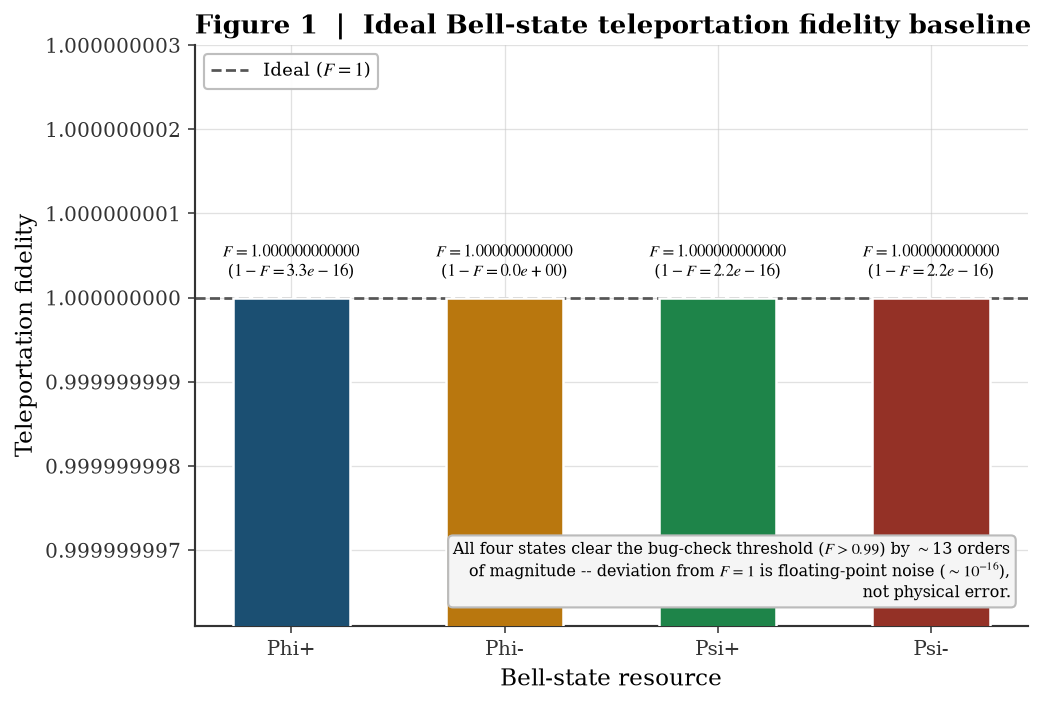

In [4]:
fids = np.array([stage1_results[b]["fidelity"] for b in BELL_LABELS])
infids = 1 - fids

fig, ax = plt.subplots(figsize=(7.6, 5.2))
bars = ax.bar(BELL_LABELS, fids, color=[PALETTE_BELL[b] for b in BELL_LABELS],
              edgecolor="white", linewidth=1.3, width=0.55, zorder=3)
ax.axhline(1.0, color=CLASSICAL_COLOR, linestyle="--", linewidth=1.4, zorder=2, label="Ideal ($F=1$)")

for bar, f, inf in zip(bars, fids, infids):
    ax.annotate(f"$F = {f:.12f}$\n($1-F = {inf:.1e}$)",
                xy=(bar.get_x() + bar.get_width() / 2, 1.0),
                xytext=(0, 8), textcoords="offset points",
                ha="center", va="bottom", fontsize=8.3)

pad = max(3e-9, infids.max() * 4)
ax.set_ylim(1 - 1.3 * pad, 1 + pad)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.9f"))
ax.set_ylabel("Teleportation fidelity")
ax.set_xlabel("Bell-state resource")
ax.set_title("Figure 1  |  Ideal Bell-state teleportation fidelity baseline", loc="left")
ax.text(0.98, 0.04,
        "All four states clear the bug-check threshold ($F>0.99$) by $\\sim$13 orders\n"
        "of magnitude -- deviation from $F=1$ is floating-point noise ($\\sim10^{-16}$),\n"
        "not physical error.",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8.2,
        bbox=dict(boxstyle="round", facecolor="#f5f5f5", edgecolor="#bbbbbb"))
ax.legend(loc="upper left", fontsize=9.5)
fig.tight_layout()
save_fig(fig, "fig01_ideal_baseline")
plt.show()

## 2. Stage 2 -- Fidelity Under the Four Noise Channels

Noise is injected on the input qubit $q_0$ before an otherwise-ideal protocol, so structurally
$\rho_B=\mathcal E(\rho_\psi)$ regardless of Bell resource -- Bob's output must be bit-for-bit identical
across all four Bell states for the three Pauli channels (Usher & Browne, Prop. 1). Fidelity is averaged
over **n = 150 Haar-random input states per (channel, p) pair** (not one fixed test state), giving an honest
average-case result with a standard-error band. Amplitude-damping is *not* a Pauli channel and is treated
separately below: it is re-simulated with the noise applied directly to the Bell pair, which is the
physically correct placement for a Bell-state-robustness study and does produce a genuine Bell-state-dependent
signal.

In [5]:
def build_noisy_teleportation_circuit(bell_label, theta, phi=0.0, channel=None, p=None):
    qr = QuantumRegister(3, "q")
    cr = ClassicalRegister(2, "c")
    qc = QuantumCircuit(qr, cr)

    qc.ry(theta, 0)
    if phi != 0.0:
        qc.p(phi, 0)

    if channel is not None:
        qc.append(Kraus(kraus_ops(channel, p)), [0])

    qc.h(1)
    qc.cx(1, 2)
    for gate in BELL_PREP[bell_label]:
        getattr(qc, gate)(2)

    qc.cx(0, 1)
    qc.h(0)
    qc.measure(0, 0)
    qc.measure(1, 1)

    with qc.if_test((cr[1], 1)):
        qc.x(2)
    with qc.if_test((cr[0], 1)):
        qc.z(2)
    for gate in BELL_PREP[bell_label]:
        getattr(qc, gate)(2)

    qc.save_density_matrix(qubits=[2], label="rho_bob")
    return qc


def build_bellpair_noisy_teleportation_circuit(bell_label, theta, phi=0.0, channel=None, p=None, noise_qubit=2):
    """Same protocol, except the noise channel is applied directly to the Bell-pair resource
    (qubit `noise_qubit`, Bob's half by default) right after Bell-state preparation and before
    the pair is consumed -- genuine 'noise on the Bell state', as opposed to input-qubit noise."""
    qr = QuantumRegister(3, "q")
    cr = ClassicalRegister(2, "c")
    qc = QuantumCircuit(qr, cr)

    qc.ry(theta, 0)
    if phi != 0.0:
        qc.p(phi, 0)

    qc.h(1)
    qc.cx(1, 2)
    for gate in BELL_PREP[bell_label]:
        getattr(qc, gate)(2)

    if channel is not None:
        qc.append(Kraus(kraus_ops(channel, p)), [noise_qubit])

    qc.cx(0, 1)
    qc.h(0)
    qc.measure(0, 0)
    qc.measure(1, 1)

    with qc.if_test((cr[1], 1)):
        qc.x(2)
    with qc.if_test((cr[0], 1)):
        qc.z(2)
    for gate in BELL_PREP[bell_label]:
        getattr(qc, gate)(2)

    qc.save_density_matrix(qubits=[2], label="rho_bob")
    return qc


def run_fidelity_batch(bell_label, thetas, phis, channel, p, bellpair_noise=False, noise_qubit=2):
    builder = build_bellpair_noisy_teleportation_circuit if bellpair_noise else build_noisy_teleportation_circuit
    kwargs = {"noise_qubit": noise_qubit} if bellpair_noise else {}
    circuits = [
        builder(bell_label, thetas[i], phis[i], channel, p, **kwargs)
        for i in range(len(thetas))
    ]
    backend = get_backend()
    result = backend.run(circuits, shots=1).result()
    fids = np.empty(len(thetas))
    for i in range(len(thetas)):
        rho_bob = np.asarray(result.data(i)["rho_bob"])
        rho_t = target_rho(thetas[i], phis[i])
        fids[i] = np.real(np.trace(rho_t @ rho_bob))
    return fids


print("Stage 2 circuit builders (input-qubit noise and Bell-pair noise) loaded OK.")

Stage 2 circuit builders (input-qubit noise and Bell-pair noise) loaded OK.


In [6]:
QUICK_TEST = False           # False = full n=150 proposal-spec sweep
N_STATES = 20 if QUICK_TEST else 150
SEED_BASE = 20260814
P_POINTS = np.linspace(0, 0.75, 11)

if QUICK_TEST:
    print("QUICK_TEST=True: using N_STATES=20 for a fast run. Set False for the full sweep.")


def run_full_sweep(bellpair_noise=False, channels=CHANNEL_LABELS, bells=BELL_LABELS, tag=""):
    t0 = time.time()
    results = {ch: {bell: [] for bell in bells} for ch in channels}
    stderr = {ch: {bell: [] for bell in bells} for ch in channels}

    for pi, p in enumerate(P_POINTS):
        thetas, phis = haar_random_states(N_STATES, seed=SEED_BASE + pi)
        for channel in channels:
            for bell in bells:
                fids = run_fidelity_batch(bell, thetas, phis, channel, p, bellpair_noise=bellpair_noise)
                results[channel][bell].append(float(np.mean(fids)))
                stderr[channel][bell].append(float(np.std(fids) / np.sqrt(N_STATES)))
        print(f"[{tag}] p={p:.3f} done ({pi + 1}/{len(P_POINTS)})  elapsed={time.time() - t0:.1f}s")

    return results, stderr


def self_check(results, tol_sigma=4):
    print("\n>>> Self-check: Haar-averaged fidelity vs. known closed forms:")
    ok = True
    for p_idx, p in enumerate(P_POINTS):
        expected_bf_pf = 1 - 2 * p / 3
        expected_dep = 1 - p / 2
        for bell in BELL_LABELS:
            for channel, expected in [("bit_flip", expected_bf_pf),
                                       ("phase_flip", expected_bf_pf),
                                       ("depolarizing", expected_dep)]:
                got = results[channel][bell][p_idx]
                tol = tol_sigma * 0.5 / np.sqrt(N_STATES)
                if abs(got - expected) > tol:
                    ok = False
                    print(f"  MISMATCH p={p:.3f} {channel} {bell}: got {got:.4f}, expected {expected:.4f}")
    print("Self-check PASSED" if ok else "Self-check FAILED -- investigate")
    return ok


def check_bell_independence(results, channels=CHANNEL_LABELS, tol=1e-9, label=""):
    print(f"--- Bell-state independence check{(' - ' + label) if label else ''} ---")
    all_match = True
    for channel in channels:
        ref = np.array(results[channel]["Phi+"])
        max_diff = 0.0
        for bell in ("Phi-", "Psi+", "Psi-"):
            diff = np.max(np.abs(np.array(results[channel][bell]) - ref))
            max_diff = max(max_diff, diff)
        verdict = "IDENTICAL across Bell states" if max_diff < tol else f"DIFFERS across Bell states (max gap = {max_diff:.4f})"
        print(f"  {channel:<20} {verdict}")
        all_match &= max_diff < tol
    print()
    return all_match


# --- Main Stage-2 sweep: noise on the input qubit (Eqs. 6-9 of the derivation) ---
stage2_results, stage2_stderr = run_full_sweep(bellpair_noise=False, tag="input-noise")
self_check(stage2_results)
check_bell_independence(stage2_results, label="input-qubit noise")

[input-noise] p=0.000 done (1/11)  elapsed=3.6s


[input-noise] p=0.075 done (2/11)  elapsed=7.8s


[input-noise] p=0.150 done (3/11)  elapsed=12.0s


[input-noise] p=0.225 done (4/11)  elapsed=16.2s


[input-noise] p=0.300 done (5/11)  elapsed=20.6s


...

[input-noise] p=0.525 done (8/11)  elapsed=32.5s


[input-noise] p=0.600 done (9/11)  elapsed=36.4s


[input-noise] p=0.675 done (10/11)  elapsed=40.5s


[input-noise] p=0.750 done (11/11)  elapsed=44.5s

>>> Self-check: Haar-averaged fidelity vs. known closed forms:
Self-check PASSED
--- Bell-state independence check - input-qubit noise ---
  bit_flip             IDENTICAL across Bell states
  phase_flip           IDENTICAL across Bell states
  depolarizing         IDENTICAL across Bell states
  amplitude_damping    IDENTICAL across Bell states



np.True_

### 2b. Bell-pair-noise confirmation

Re-runs the *exact* same Haar draws with the noise channel applied directly to the Bell pair instead of the
input qubit, state-by-state. For the three Pauli channels this must agree with the input-noise result to
floating-point precision (Usher & Browne, Prop. 1); for amplitude-damping -- which is not a Pauli channel and
is non-unital -- a real, physically meaningful difference is expected, and this Bell-pair version is the one
carried forward for all later amplitude-damping figures, since it is the physically correct placement for a
Bell-state-robustness study.

In [7]:
def run_bellpair_confirmation_sweep():
    t0 = time.time()
    bp_results = {ch: {bell: [] for bell in BELL_LABELS} for ch in CHANNEL_LABELS}
    bp_stderr = {ch: {bell: [] for bell in BELL_LABELS} for ch in CHANNEL_LABELS}
    max_abs_diff = {ch: 0.0 for ch in CHANNEL_LABELS}

    for pi, p in enumerate(P_POINTS):
        thetas, phis = haar_random_states(N_STATES, seed=SEED_BASE + pi)  # identical draw to main sweep
        for channel in CHANNEL_LABELS:
            for bell in BELL_LABELS:
                fids_input = run_fidelity_batch(bell, thetas, phis, channel, p, bellpair_noise=False)
                fids_bell = run_fidelity_batch(bell, thetas, phis, channel, p, bellpair_noise=True)
                bp_results[channel][bell].append(float(np.mean(fids_bell)))
                bp_stderr[channel][bell].append(float(np.std(fids_bell) / np.sqrt(N_STATES)))
                max_abs_diff[channel] = max(max_abs_diff[channel], float(np.max(np.abs(fids_input - fids_bell))))
        print(f"[bell-pair-confirm] p={p:.3f} done ({pi + 1}/{len(P_POINTS)})  elapsed={time.time() - t0:.1f}s")

    return bp_results, bp_stderr, max_abs_diff


bellpair_results, bellpair_stderr, max_abs_diff = run_bellpair_confirmation_sweep()

print("\n>>> Confirmation: input-qubit noise vs. Bell-pair noise")
print("(max, over every drawn state / Bell state / p, of |F_input - F_bellpair|)\n")
for ch in CHANNEL_LABELS:
    tag = "Pauli channel -> expect ~0 (Usher & Browne Prop. 1)" if ch != "amplitude_damping" \
          else "NOT a Pauli channel -> expect a real, nonzero difference"
    print(f"  {ch:<20} max|diff| = {max_abs_diff[ch]:.2e}    [{tag}]")

check_bell_independence(bellpair_results, channels=["bit_flip", "phase_flip", "depolarizing"],
                         label="bell-pair noise, Pauli channels")
check_bell_independence(bellpair_results, channels=["amplitude_damping"],
                         label="bell-pair noise, amplitude-damping")

p_max_idx = len(P_POINTS) - 1
print(f"Amplitude-damping fidelity per Bell state at p={P_POINTS[p_max_idx]:.2f} (bell-pair noise):")
for bell in BELL_LABELS:
    print(f"  {bell:<6} F = {bellpair_results['amplitude_damping'][bell][p_max_idx]:.4f}")

# Build the corrected results/stderr used for every downstream Stage-2 figure/table:
# Pauli channels keep the (numerically identical) input-noise numbers; amplitude-damping
# is replaced with the physically correct Bell-pair-noise numbers.
stage2_results_confirmed = {ch: dict(stage2_results[ch]) for ch in CHANNEL_LABELS}
stage2_stderr_confirmed = {ch: dict(stage2_stderr[ch]) for ch in CHANNEL_LABELS}
stage2_results_confirmed["amplitude_damping"] = dict(bellpair_results["amplitude_damping"])
stage2_stderr_confirmed["amplitude_damping"] = dict(bellpair_stderr["amplitude_damping"])
print("\nstage2_results_confirmed built (Pauli channels unchanged; amplitude-damping replaced "
      "with the Bell-pair-noise version).")

[bell-pair-confirm] p=0.000 done (1/11)  elapsed=7.6s


[bell-pair-confirm] p=0.075 done (2/11)  elapsed=16.1s


[bell-pair-confirm] p=0.150 done (3/11)  elapsed=24.4s


[bell-pair-confirm] p=0.225 done (4/11)  elapsed=32.5s


[bell-pair-confirm] p=0.300 done (5/11)  elapsed=40.1s


...

[bell-pair-confirm] p=0.450 done (7/11)  elapsed=55.9s


[bell-pair-confirm] p=0.525 done (8/11)  elapsed=63.9s


[bell-pair-confirm] p=0.600 done (9/11)  elapsed=71.4s


[bell-pair-confirm] p=0.675 done (10/11)  elapsed=79.3s


[bell-pair-confirm] p=0.750 done (11/11)  elapsed=87.2s

>>> Confirmation: input-qubit noise vs. Bell-pair noise
(max, over every drawn state / Bell state / p, of |F_input - F_bellpair|)

  bit_flip             max|diff| = 6.66e-16    [Pauli channel -> expect ~0 (Usher & Browne Prop. 1)]
  phase_flip           max|diff| = 5.55e-16    [Pauli channel -> expect ~0 (Usher & Browne Prop. 1)]
  depolarizing         max|diff| = 5.55e-16    [Pauli channel -> expect ~0 (Usher & Browne Prop. 1)]
  amplitude_damping    max|diff| = 7.41e-01    [NOT a Pauli channel -> expect a real, nonzero difference]
--- Bell-state independence check - bell-pair noise, Pauli channels ---
  bit_flip             IDENTICAL across Bell states
  phase_flip           IDENTICAL across Bell states
  depolarizing         IDENTICAL across Bell states

--- Bell-state independence check - bell-pair noise, amplitude-damping ---
  amplitude_damping    DIFFERS across Bell states (max gap = 0.0454)

Amplitude-damping fidelity pe

### 2c. QuTiP independent cross-check

Cross-checks the fixed test state ($\alpha=\sqrt3/2,\ \beta=1/2$) three independent ways: full gate-level
Qiskit simulation, the hand-derived closed-form formulas, and an independent QuTiP simulation.

In [8]:
def qutip_kraus_ops(channel, p):
    I2q, Xq, Yq, Zq = qt.qeye(2), qt.sigmax(), qt.sigmay(), qt.sigmaz()
    if channel == "bit_flip":
        return [np.sqrt(1 - p) * I2q, np.sqrt(p) * Xq]
    elif channel == "phase_flip":
        return [np.sqrt(1 - p) * I2q, np.sqrt(p) * Zq]
    elif channel == "depolarizing":
        return [np.sqrt(1 - 3 * p / 4) * I2q, np.sqrt(p / 4) * Xq,
                np.sqrt(p / 4) * Yq, np.sqrt(p / 4) * Zq]
    elif channel == "amplitude_damping":
        gamma = p
        E0 = qt.Qobj([[1, 0], [0, np.sqrt(1 - gamma)]])
        E1 = qt.Qobj([[0, np.sqrt(gamma)], [0, 0]])
        return [E0, E1]
    else:
        raise ValueError(f"Unknown channel {channel!r}")


def qutip_channel_fidelity(channel, p, alpha, beta):
    psi = qt.Qobj([[alpha], [beta]])
    rho_psi = psi * psi.dag()
    kraus = qutip_kraus_ops(channel, p)
    rho_out = sum(K * rho_psi * K.dag() for K in kraus)
    F = (psi.dag() * rho_out * psi)
    F = F[0, 0] if hasattr(F, "__getitem__") else F
    return np.real(F), rho_out


def run_crosscheck(tol=1e-6):
    print(f"Fixed test state: alpha={ALPHA:.6f}, beta={BETA:.6f}\n")
    all_ok = True
    rows = []
    for channel in CHANNEL_LABELS:
        for p in P_POINTS:
            f_aer = np.mean(run_fidelity_batch("Phi+", np.array([THETA_FIXED]), np.array([0.0]), channel, p))
            f_closed = closed_form_fidelity(channel, p)
            f_qutip, _ = qutip_channel_fidelity(channel, p, ALPHA, BETA)
            agree = abs(f_aer - f_closed) < tol and abs(f_aer - f_qutip) < tol
            all_ok &= agree
            rows.append((channel, p, f_aer, f_closed, f_qutip, agree))

    print(f"{'channel':<18}{'p':>6}  {'Aer':>10}  {'closed-form':>12}  {'QuTiP':>10}  match")
    print("-" * 66)
    for channel, p, f_aer, f_closed, f_qutip, agree in rows:
        print(f"{channel:<18}{p:>6.3f}  {f_aer:>10.6f}  {f_closed:>12.6f}  {f_qutip:>10.6f}  {'OK' if agree else 'MISMATCH'}")
    print("\nALL AGREE (Aer == closed-form == QuTiP, to 1e-6)" if all_ok else "\nSOME MISMATCHES -- investigate")
    return rows, all_ok


_ = run_crosscheck()

Fixed test state: alpha=0.866025, beta=0.500000

channel                p         Aer   closed-form       QuTiP  match
------------------------------------------------------------------
bit_flip           0.000    1.000000      1.000000    1.000000  OK
bit_flip           0.075    0.981250      0.981250    0.981250  OK
bit_flip           0.150    0.962500      0.962500    0.962500  OK
bit_flip           0.225    0.943750      0.943750    0.943750  OK
bit_flip           0.300    0.925000      0.925000    0.925000  OK
bit_flip           0.375    0.906250      0.906250    0.906250  OK
bit_flip           0.450    0.887500      0.887500    0.887500  OK
bit_flip           0.525    0.868750      0.868750    0.868750  OK
bit_flip           0.600    0.850000      0.850000    0.850000  OK
bit_flip           0.675    0.831250      0.831250    0.831250  OK
bit_flip           0.750    0.812500      0.812500    0.812500  OK
phase_flip         0.000    1.000000      1.000000    1.000000  OK
phase_flip

### 2d. Figures -- fidelity vs. noise strength, all four channels (2x2 panel)

One consolidated figure (four panels, one per channel) instead of four separate pop-outs: each panel shows
all four Bell-state curves with shaded $\pm1$ standard-error bands and the classical benchmark $F=2/3$. For
bit-flip, phase-flip, and depolarizing the four curves are numerically on top of each other (confirmed in
\u00a72c); amplitude-damping is the one panel where they visibly separate.

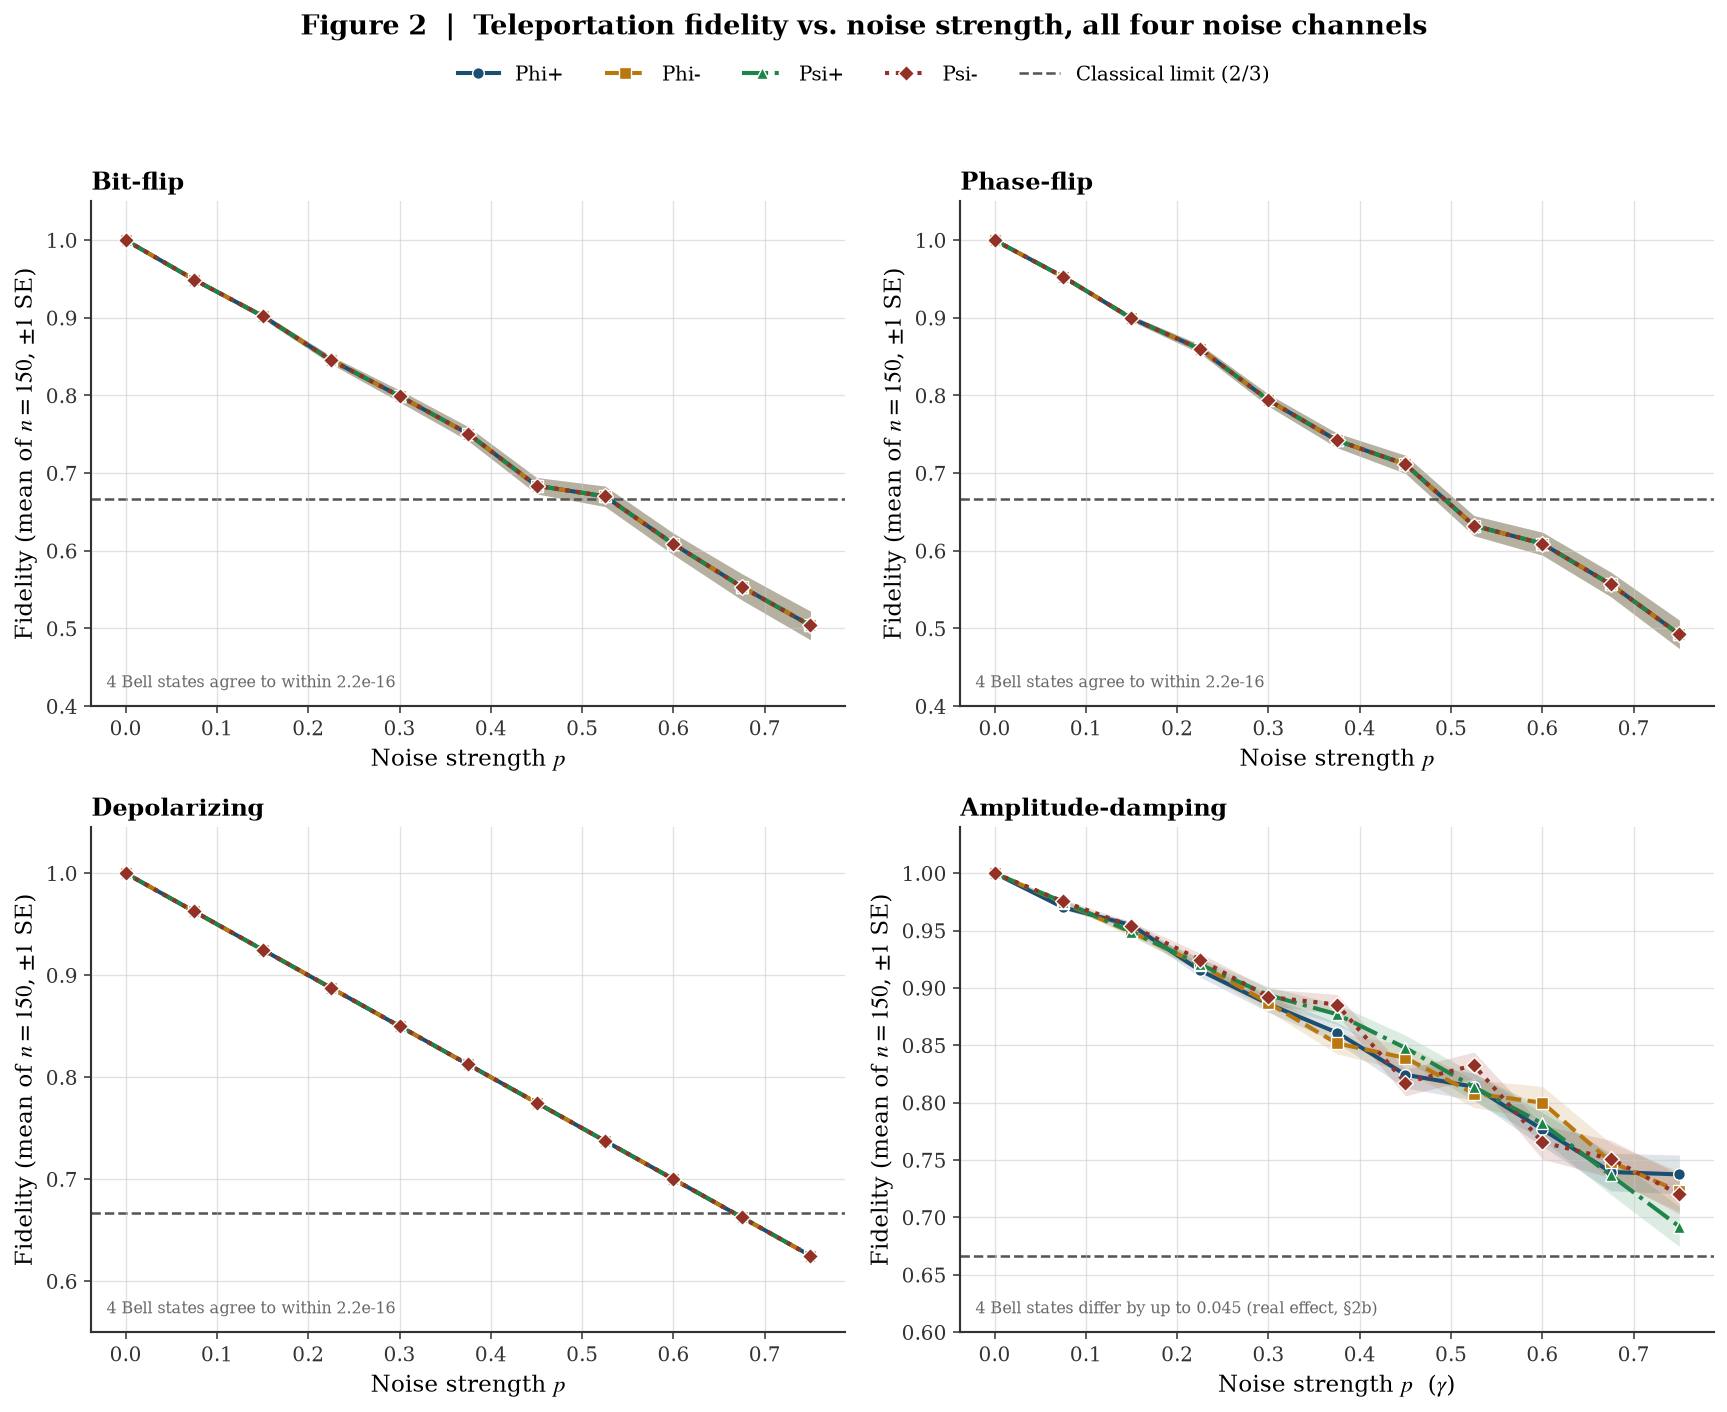


At p = 0.750 (maximum noise):
  LEAST robust: phase_flip / Psi+ (F = 0.4925)
  MOST robust:  amplitude_damping / Phi+ (F = 0.7375)


,p=0.000,p=0.075,p=0.150,p=0.225,p=0.300,p=0.375,p=0.450,p=0.525,p=0.600,p=0.675,p=0.750
channel,,,,,,,,,,,
bit_flip,1.0000,0.9491,0.9024,0.8456,0.7992,0.7508,0.6838,0.6702,0.6087,0.5535,0.5039
phase_flip,1.0000,0.9529,0.8993,0.8600,0.7940,0.7421,0.7114,0.6325,0.6092,0.5567,0.4925
depolarizing,1.0000,0.9625,0.9250,0.8875,0.8500,0.8125,0.7750,0.7375,0.7000,0.6625,0.6250
amplitude_damping,1.0000,0.9702,0.9547,0.9154,0.8860,0.8611,0.8244,0.8139,0.7767,0.7396,0.7375


In [9]:
def make_stage2_channel_grid(results, stderr, filename="fig02_channel_grid"):
    fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.5))
    axes = axes.ravel()

    for ax, (channel, title) in zip(axes, CHANNEL_TITLES.items()):
        all_curve_vals = []
        for bell in BELL_LABELS:
            means = np.array(results[channel][bell])
            errs = np.array(stderr[channel][bell])
            ax.plot(P_POINTS, means, label=bell, color=PALETTE_BELL[bell],
                    marker=BELL_MARKERS[bell], linestyle=BELL_LINESTYLES[bell],
                    linewidth=2.1, markersize=6)
            ax.fill_between(P_POINTS, means - errs, means + errs,
                             color=PALETTE_BELL[bell], alpha=0.15, linewidth=0)
            all_curve_vals += [means - errs, means + errs]

        all_bell_means = np.array([results[channel][b] for b in BELL_LABELS])
        max_gap = float(np.max(np.abs(all_bell_means - all_bell_means[0])))

        ax.axhline(F_CLASSICAL, color=CLASSICAL_COLOR, linestyle="--", linewidth=1.3, zorder=1,
                   label="Classical limit (2/3)")

        xlabel = "Noise strength $p$" + ("  ($\\gamma$)" if channel == "amplitude_damping" else "")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(f"Fidelity (mean of $n={N_STATES}$, $\\pm1$ SE)")
        auto_ylim(ax, all_curve_vals, refs=(F_CLASSICAL,))
        ax.set_title(title, loc="left", fontsize=12.5)
        gap_note = (f"agree to within {max_gap:.1e}" if max_gap < 1e-6
                    else f"differ by up to {max_gap:.3f} (real effect, \u00a72b)")
        ax.text(0.02, 0.03, f"4 Bell states {gap_note}", transform=ax.transAxes,
                fontsize=8, color="dimgray", va="bottom")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=5, fontsize=10.5,
               bbox_to_anchor=(0.5, 1.035), frameon=False)
    fig.suptitle("Figure 2  |  Teleportation fidelity vs. noise strength, all four noise channels",
                 fontsize=14, fontweight="bold", y=1.06)
    fig.tight_layout(rect=[0, 0, 1, 1.0])
    save_fig(fig, filename)
    plt.show()


def make_table1(results):
    rows = [["channel", "bell_state"] + [f"p={p:.3f}" for p in P_POINTS]]
    for channel in CHANNEL_TITLES:
        for bell in BELL_LABELS:
            rows.append([channel, bell] + [f"{m:.4f}" for m in results[channel][bell]])

    last_idx = len(P_POINTS) - 1
    flat = sorted(
        ((channel, bell, results[channel][bell][last_idx])
         for channel in CHANNEL_TITLES for bell in BELL_LABELS),
        key=lambda x: x[2],
    )
    print(f"\nAt p = {P_POINTS[last_idx]:.3f} (maximum noise):")
    print(f"  LEAST robust: {flat[0][0]} / {flat[0][1]} (F = {flat[0][2]:.4f})")
    print(f"  MOST robust:  {flat[-1][0]} / {flat[-1][1]} (F = {flat[-1][2]:.4f})")

    df = pd.DataFrame(rows[1:], columns=rows[0])
    pivot = df[df["bell_state"] == "Phi+"].drop(columns="bell_state").set_index("channel")
    styled = pivot.style.set_caption(
        "Table 1 (excerpt): fidelity vs. p, Phi+ shown -- identical for all 4 Bell states for "
        "bit-flip/phase-flip/depolarizing (confirmed \u00a72c); amplitude-damping genuinely "
        "differs by Bell state, see Figure 2 (bottom-right panel)."
    ).background_gradient(cmap="RdYlGn", axis=1, vmin=0.4, vmax=1.0)
    display(styled)
    return flat


make_stage2_channel_grid(stage2_results_confirmed, stage2_stderr_confirmed)
_ = make_table1(stage2_results_confirmed)

### 2e. Cross-channel comparison and ranking

Answers "for a fixed Bell state, which noise channel hurts fidelity fastest?" using `Phi+` as the
representative Bell state (exact for the three Pauli channels; amplitude-damping's other three curves are
overlaid faintly since it is *not* Bell-independent).

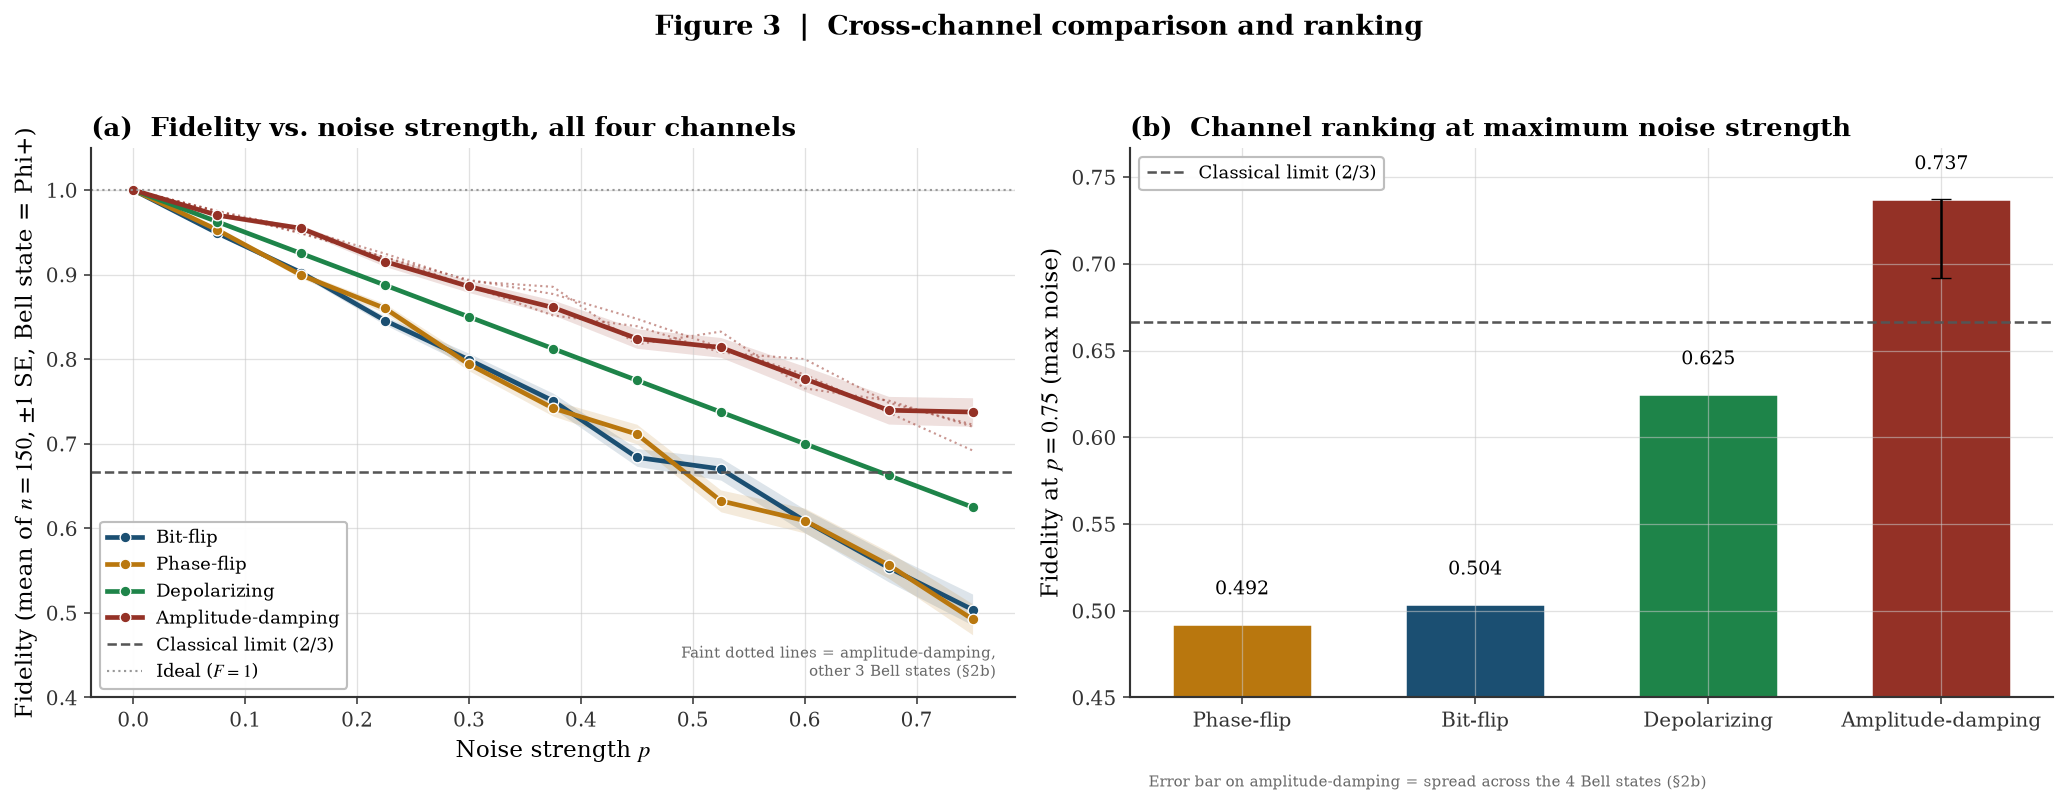


At p=0.750, ranked least -> most robust (bell=Phi+):
  Phase-flip           F = 0.4925
  Bit-flip             F = 0.5039
  Depolarizing         F = 0.6250
  Amplitude-damping    F = 0.7375
  (amplitude-damping spread across Bell states: 0.6921 to 0.7375)


In [10]:
def make_channel_comparison_and_ranking(results, stderr, bell="Phi+"):
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15, 5.8))

    all_curve_vals = []
    for channel, title in CHANNEL_TITLES.items():
        means = np.array(results[channel][bell])
        errs = np.array(stderr[channel][bell])
        ax.plot(P_POINTS, means, label=title, linewidth=2.4, marker="o", markersize=5.5,
                color=PALETTE_CHANNEL[channel])
        ax.fill_between(P_POINTS, means - errs, means + errs,
                         color=PALETTE_CHANNEL[channel], alpha=0.15, linewidth=0)
        all_curve_vals += [means - errs, means + errs]
        if channel == "amplitude_damping":
            for other_bell in BELL_LABELS:
                if other_bell == bell:
                    continue
                other_means = np.array(results[channel][other_bell])
                ax.plot(P_POINTS, other_means, linewidth=1.1, linestyle=":",
                        color=PALETTE_CHANNEL[channel], alpha=0.5, zorder=1)
                all_curve_vals.append(other_means)

    ax.axhline(F_CLASSICAL, color=CLASSICAL_COLOR, linestyle="--", linewidth=1.3, label="Classical limit (2/3)")
    ax.axhline(1.0, color=IDEAL_COLOR, linestyle=":", linewidth=1.1, label="Ideal ($F=1$)")
    ax.set_xlabel("Noise strength $p$")
    ax.set_ylabel(f"Fidelity (mean of $n={N_STATES}$, $\\pm1$ SE, Bell state = {bell})")
    auto_ylim(ax, all_curve_vals, refs=(F_CLASSICAL, 1.0))
    ax.set_title("(a)  Fidelity vs. noise strength, all four channels", loc="left")
    ax.text(0.98, 0.03,
            "Faint dotted lines = amplitude-damping,\nother 3 Bell states (\u00a72b)",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=7.8, color="dimgray")
    ax.legend(loc="lower left", fontsize=9, ncol=1)

    p_max_idx = len(P_POINTS) - 1
    channels = list(CHANNEL_TITLES.keys())
    finals = [results[c][bell][p_max_idx] for c in channels]
    order = np.argsort(finals)
    channels_sorted = [channels[i] for i in order]
    finals_sorted = [finals[i] for i in order]

    ad_spread = None
    if "amplitude_damping" in channels_sorted:
        ad_vals_all_bells = [results["amplitude_damping"][b][p_max_idx] for b in BELL_LABELS]
        ad_spread = (min(ad_vals_all_bells), max(ad_vals_all_bells))

    bars = ax2.bar([CHANNEL_TITLES[c] for c in channels_sorted], finals_sorted,
                    color=[PALETTE_CHANNEL[c] for c in channels_sorted], edgecolor="white", linewidth=1.3, width=0.6)
    ax2.axhline(F_CLASSICAL, color=CLASSICAL_COLOR, linestyle="--", linewidth=1.3, label="Classical limit (2/3)")
    for bar, val, c in zip(bars, finals_sorted, channels_sorted):
        ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.017, f"{val:.3f}", ha="center", fontsize=10)
        if c == "amplitude_damping" and ad_spread is not None:
            lo, hi = ad_spread
            ax2.errorbar(bar.get_x() + bar.get_width() / 2, val, yerr=[[val - lo], [hi - val]],
                         fmt="none", ecolor="black", elinewidth=1.3, capsize=5, zorder=5)

    bar_vals_for_ylim = list(finals_sorted) + (list(ad_spread) if ad_spread else [])
    ax2.set_ylabel(f"Fidelity at $p={P_POINTS[p_max_idx]:.2f}$ (max noise)")
    ax2.set_title("(b)  Channel ranking at maximum noise strength", loc="left")
    auto_ylim(ax2, [bar_vals_for_ylim], refs=(F_CLASSICAL,))
    ax2.legend(loc="upper left", fontsize=9.5)
    if ad_spread is not None:
        ax2.text(0.02, -0.14, "Error bar on amplitude-damping = spread across the 4 Bell states (\u00a72b)",
                 transform=ax2.transAxes, ha="left", va="top", fontsize=7.6, color="dimgray")

    fig.suptitle("Figure 3  |  Cross-channel comparison and ranking", fontsize=14, fontweight="bold", y=1.03)
    fig.tight_layout(rect=[0, 0.03, 1, 1])
    save_fig(fig, "fig03_channel_comparison_and_ranking")
    plt.show()

    print(f"\nAt p={P_POINTS[p_max_idx]:.3f}, ranked least -> most robust (bell={bell}):")
    for c, f in zip(channels_sorted, finals_sorted):
        print(f"  {CHANNEL_TITLES[c]:<20} F = {f:.4f}")
    if ad_spread is not None:
        print(f"  (amplitude-damping spread across Bell states: {ad_spread[0]:.4f} to {ad_spread[1]:.4f})")

    return channels_sorted, finals_sorted


_ = make_channel_comparison_and_ranking(stage2_results_confirmed, stage2_stderr_confirmed)

## 3. Stage 3 -- Routing Noise: Natural vs. Forced-SWAP Layout

Real chips only allow directly-wired qubits to interact. If a circuit needs two unwired qubits to interact,
the compiler inserts a SWAP, and an ideal SWAP decomposes into three extra two-qubit gates -- each carrying
real, measurable hardware error. This section builds a natural (connectivity-respecting) and a forced
(extra-SWAP) version of the same teleportation circuit, transpiles both onto three physically adjacent qubits
of `FakeSherbrooke` (a locally bundled snapshot of real calibration data from an actual 127-qubit IBM chip),
and compares a calibration-only prediction against a full noisy simulation.

In [11]:
CNOT = np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=complex)
CNOT_rev = np.array([[1, 0, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0], [0, 1, 0, 0]], dtype=complex)
SWAP_MAT = np.array([[1, 0, 0, 0], [0, 0, 1, 0], [0, 1, 0, 0], [0, 0, 0, 1]], dtype=complex)

built_from_cnots = CNOT @ CNOT_rev @ CNOT
match = np.allclose(built_from_cnots, SWAP_MAT)
print("CNOT(a,b)-CNOT(b,a)-CNOT(a,b) equals SWAP:", match)
assert match, "identity failed -- check basis/ordering convention"
print("=> every SWAP the compiler inserts costs 3 real two-qubit gates, not 1.")

CNOT(a,b)-CNOT(b,a)-CNOT(a,b) equals SWAP: True
=> every SWAP the compiler inserts costs 3 real two-qubit gates, not 1.


In [12]:
def build_natural(bell_label, theta, phi=0.0):
    qr = QuantumRegister(3, "q")
    cr = ClassicalRegister(2, "c")
    qc = QuantumCircuit(qr, cr)

    qc.ry(theta, 0)
    if phi != 0.0:
        qc.p(phi, 0)

    qc.h(1)
    qc.cx(1, 2)
    for g in BELL_PREP[bell_label]:
        getattr(qc, g)(2)

    qc.cx(0, 1)
    qc.h(0)
    qc.measure(0, 0)
    qc.measure(1, 1)

    with qc.if_test((cr[1], 1)):
        qc.x(2)
    with qc.if_test((cr[0], 1)):
        qc.z(2)
    for g in BELL_PREP[bell_label]:
        getattr(qc, g)(2)
    return qc


def build_forced(bell_label, theta, phi=0.0):
    """Forced layout: 0=q0 (input), 1=q2 (Bob's qubit initially), 2=q1 (Alice's ancilla initially).
    One SWAP is inserted before the Bell measurement to make q1 adjacent to q0."""
    qr = QuantumRegister(3, "q")
    cr = ClassicalRegister(2, "c")
    qc = QuantumCircuit(qr, cr)

    qc.ry(theta, 0)
    if phi != 0.0:
        qc.p(phi, 0)

    qc.h(2)
    qc.cx(2, 1)
    for g in BELL_PREP[bell_label]:
        getattr(qc, g)(1)

    qc.swap(1, 2)

    qc.cx(0, 1)
    qc.h(0)
    qc.measure(0, 0)
    qc.measure(1, 1)

    with qc.if_test((cr[1], 1)):
        qc.x(2)
    with qc.if_test((cr[0], 1)):
        qc.z(2)
    for g in BELL_PREP[bell_label]:
        getattr(qc, g)(2)
    return qc


print("Natural- and forced-layout circuit builders are defined.")

Natural- and forced-layout circuit builders are defined.


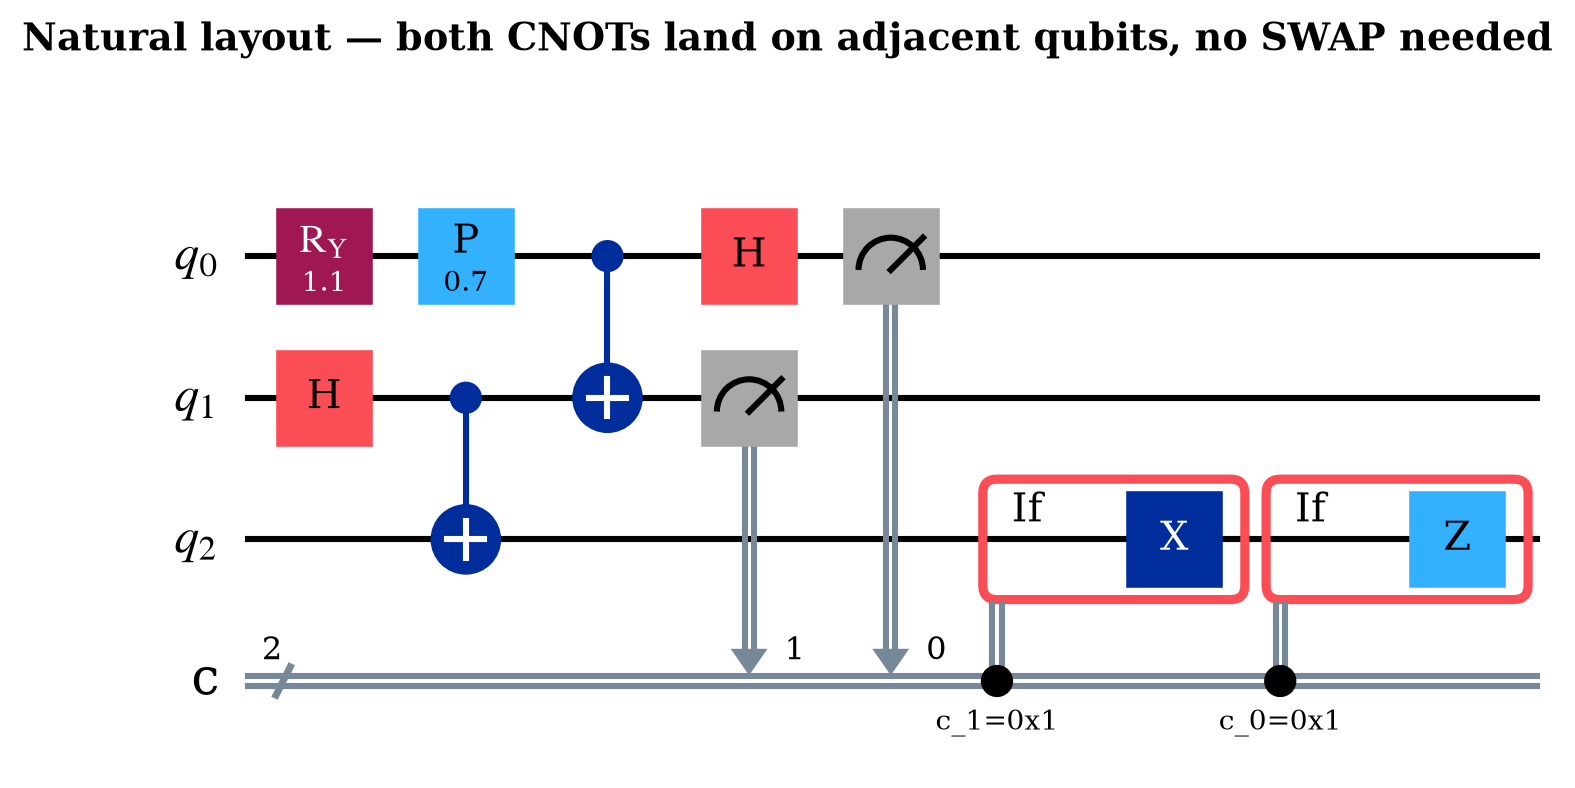

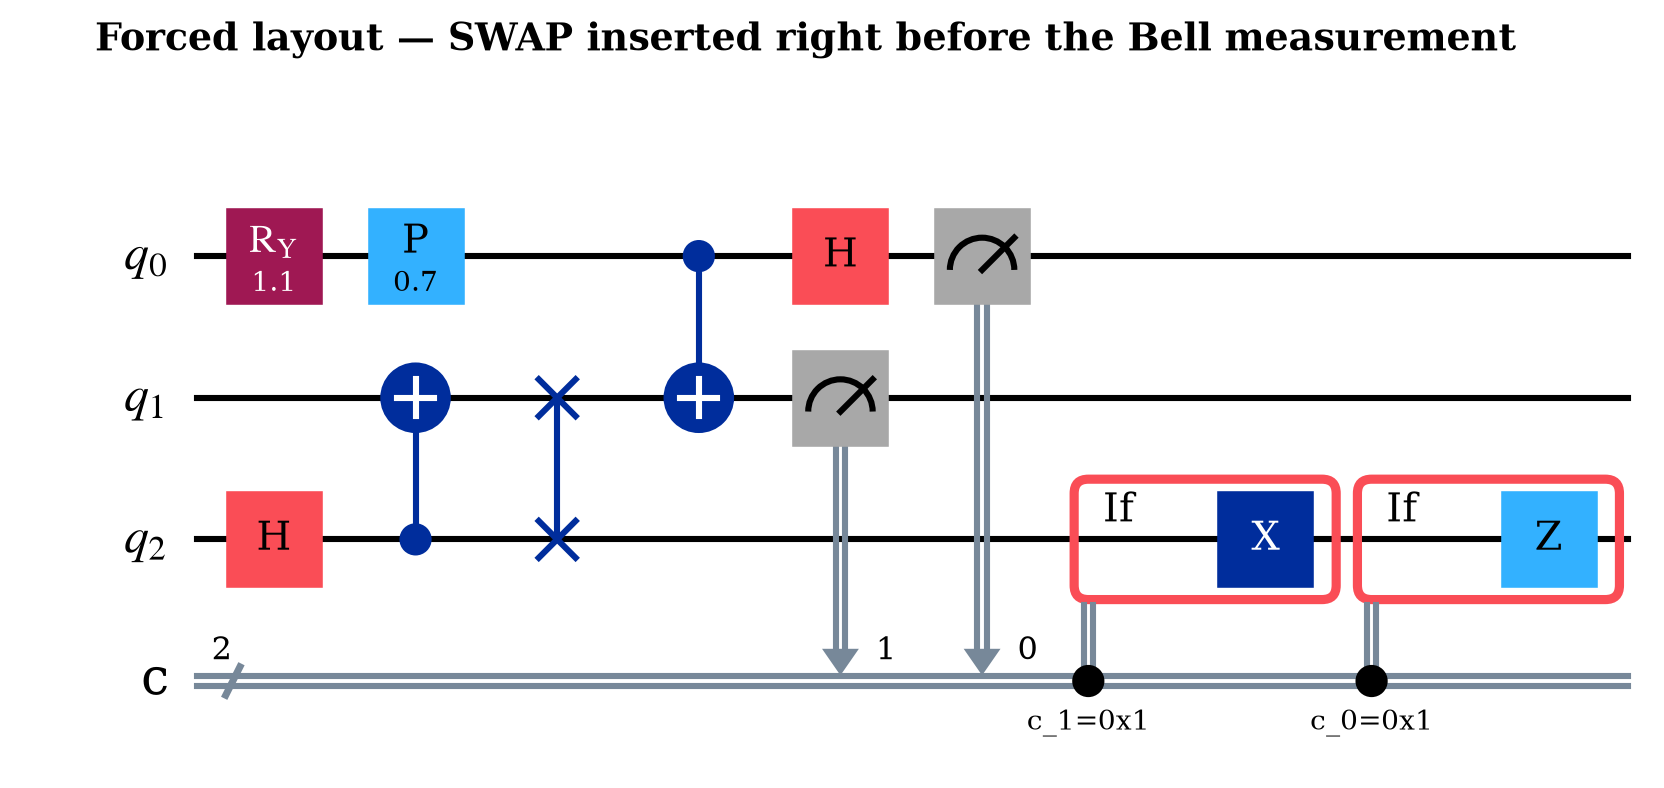

natural: 2 two-qubit gate(s)  |  forced: 3 two-qubit gate(s) (1 of which is a SWAP -> 3 CNOTs once transpiled)


In [13]:
qc_natural_demo = build_natural("Phi+", theta=1.1, phi=0.7)
qc_forced_demo = build_forced("Phi+", theta=1.1, phi=0.7)

draw_circuit(qc_natural_demo, "Natural layout \u2014 both CNOTs land on adjacent qubits, no SWAP needed",
             "fig04a_natural_circuit_logical")
draw_circuit(qc_forced_demo, "Forced layout \u2014 SWAP inserted right before the Bell measurement",
             "fig04b_forced_circuit_logical")

n2q_nat = sum(1 for i in qc_natural_demo.data if i.operation.name in ("cx", "swap"))
n2q_forced = sum(1 for i in qc_forced_demo.data if i.operation.name in ("cx", "swap"))
print(f"natural: {n2q_nat} two-qubit gate(s)  |  forced: {n2q_forced} two-qubit gate(s) "
      f"(1 of which is a SWAP -> 3 CNOTs once transpiled)")

### 3a. Ideal-case correctness check (both layouts, before any hardware noise)

In [14]:
ideal_backend = AerSimulator(method="density_matrix")
theta_test, phi_test = 1.1, 0.7
psi_rho_test = target_rho(theta_test, phi_test)

print(f"{'Layout':<10}{'Bell state':<12}{'Fidelity':>10}   Status")
print("-" * 46)
all_ok = True
for build_fn, layout_name in [(build_natural, "natural"), (build_forced, "forced")]:
    for bell in BELL_LABELS:
        qc = build_fn(bell, theta_test, phi_test)
        qc.save_density_matrix(qubits=[2], label="rho_bob")
        res = ideal_backend.run(qc, shots=1).result()
        rho_bob = np.asarray(res.data(0)["rho_bob"])
        fid = np.real(np.trace(psi_rho_test @ rho_bob))
        ok = fid > 0.999999
        all_ok &= ok
        print(f"{layout_name:<10}{bell:<12}{fid:>10.6f}   {'OK' if ok else 'FAIL (bug!)'}")

print("\nAll ideal-case checks passed." if all_ok else "\nSOME CHECKS FAILED -- investigate before continuing.")

Layout    Bell state    Fidelity   Status
----------------------------------------------
natural   Phi+          1.000000   OK
natural   Phi-          1.000000   OK
natural   Psi+          1.000000   OK
natural   Psi-          1.000000   OK
forced    Phi+          1.000000   OK
forced    Phi-          1.000000   OK
forced    Psi+          1.000000   OK
forced    Psi-          1.000000   OK

All ideal-case checks passed.


### 3b. Real chip calibration data (`FakeSherbrooke`)

In [15]:
fake_backend = FakeSherbrooke()
cmap_edges = {(min(a, b), max(a, b)) for a, b in fake_backend.coupling_map.get_edges()}

# Find a physical path P0-P1-P2: edges (P0,P1) and (P1,P2) exist, but (P0,P2) does not.
found = None
for p1 in range(fake_backend.num_qubits):
    neighbors = {b for (a, b) in cmap_edges if a == p1} | {a for (a, b) in cmap_edges if b == p1}
    neighbors = list(neighbors)
    for i, p0 in enumerate(neighbors):
        for p2 in neighbors[i + 1:]:
            edge = (min(p0, p2), max(p0, p2))
            if edge not in cmap_edges:
                found = (p0, p1, p2)
                break
        if found:
            break
    if found:
        break

P0, P1, P2 = found
print(f"Using real physical qubits P0={P0}, P1={P1}, P2={P2} on FakeSherbrooke "
      f"(edges (P0,P1) and (P1,P2) exist; (P0,P2) does not).")

TWOQ_GATE = "ecr"
ecr_props = fake_backend.target[TWOQ_GATE]


def edge_error(a, b):
    """Get the real calibrated 2-qubit gate error for this edge."""
    ip = ecr_props.get((a, b)) or ecr_props.get((b, a))
    if ip is None:
        raise ValueError(f"No calibration found for edge ({a},{b})")
    return ip.error


err_P0P1 = edge_error(P0, P1)
err_P1P2 = edge_error(P1, P2)
print(f"Calibrated {TWOQ_GATE} error, edge (P0,P1): {err_P0P1:.4%}")
print(f"Calibrated {TWOQ_GATE} error, edge (P1,P2): {err_P1P2:.4%}")

noisy_sim = AerSimulator.from_backend(fake_backend)

Using real physical qubits P0=1, P1=0, P2=14 on FakeSherbrooke (edges (P0,P1) and (P1,P2) exist; (P0,P2) does not).
Calibrated ecr error, edge (P0,P1): 0.7494%
Calibrated ecr error, edge (P1,P2): 0.7845%


### 3c. Qubit-role diagram

findfont: Failed to find font weight medium, now using 400.


findfont: Failed to find font weight medium, now using 400.


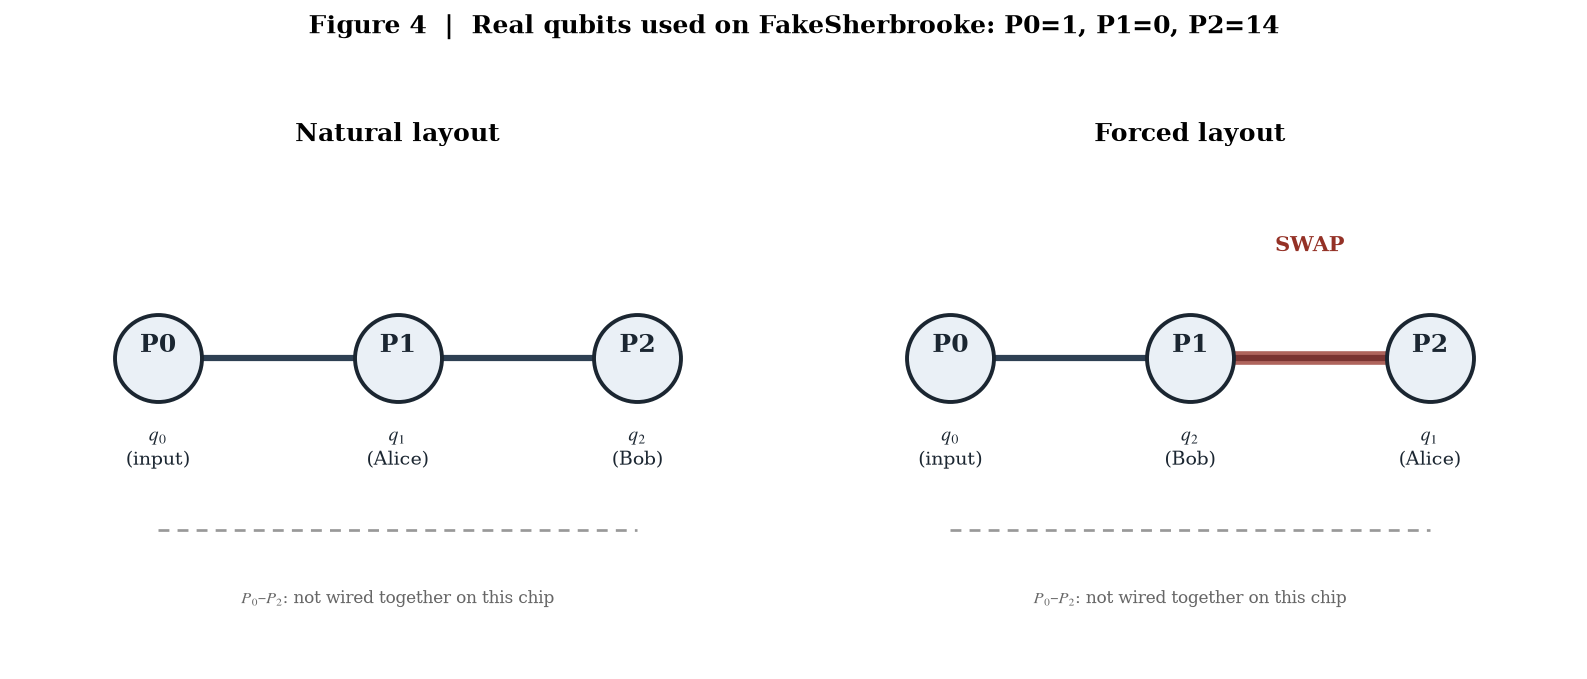

In [16]:
def make_qubit_role_diagram(filename="fig05_qubit_role_diagram"):
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

    node_x = {P0: 0, P1: 1, P2: 2}
    real_edges = [(P0, P1), (P1, P2)]

    layout_roles = [
        ("Natural layout", {P0: "$q_0$\n(input)", P1: "$q_1$\n(Alice)", P2: "$q_2$\n(Bob)"}, None),
        ("Forced layout", {P0: "$q_0$\n(input)", P1: "$q_2$\n(Bob)", P2: "$q_1$\n(Alice)"}, (P1, P2)),
    ]

    for ax, (title, roles, swap_edge) in zip(axes, layout_roles):
        for a, b in real_edges:
            ax.plot([node_x[a], node_x[b]], [0, 0], color="#2E4053", lw=3.2, zorder=1,
                    solid_capstyle="round")
        ax.plot([node_x[P0], node_x[P2]], [-0.42, -0.42], color="#999999", lw=1.4, ls=(0, (4, 3)), zorder=0)
        ax.text(1, -0.60, "$P_0$\u2013$P_2$: not wired together on this chip",
                ha="center", fontsize=8.5, color="#666666")

        if swap_edge:
            a, b = swap_edge
            ax.plot([node_x[a], node_x[b]], [0, 0], color="#943126", lw=7, alpha=0.75, zorder=2,
                    solid_capstyle="round")
            ax.text((node_x[a] + node_x[b]) / 2, 0.26, "SWAP", ha="center", fontsize=11,
                    color="#943126", fontweight="bold")

        for phys_q, x in node_x.items():
            ax.scatter([x], [0], s=2000, color="#EAF0F6", edgecolor="#1B2631", lw=2.0, zorder=3)
            ax.text(x, 0.03, f"P{[P0, P1, P2].index(phys_q)}", ha="center", va="center",
                    fontsize=13, fontweight="bold", color="#1B2631", zorder=4)
            ax.text(x, -0.22, roles[phys_q], ha="center", va="center", fontsize=10,
                    color="#1B2631", fontweight="medium", zorder=4)

        ax.set_xlim(-0.6, 2.6)
        ax.set_ylim(-0.75, 0.5)
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.axis("off")

    fig.suptitle(f"Figure 4  |  Real qubits used on FakeSherbrooke: P0={P0}, P1={P1}, P2={P2}",
                 fontsize=13, fontweight="bold", y=1.05)
    fig.tight_layout()
    save_fig(fig, filename)
    plt.show()


make_qubit_role_diagram()

### 3d. Transpiled circuits: gate-count validation

In [17]:
def transpile_circuit(build_fn, bell_label, theta, phi):
    """Transpile a circuit onto the real chip's coupling map."""
    qc = build_fn(bell_label, theta, phi)
    tqc = transpile(qc, backend=noisy_sim, initial_layout=[P0, P1, P2],
                     routing_method="none", optimization_level=1)
    tqc.save_density_matrix(qubits=[P2], label="rho_bob")
    return tqc


print("TRANSPILED CIRCUIT GATE COUNT VALIDATION")
print("-" * 80)

for build_fn, layout_name, expected_2q in [(build_natural, "natural", 2), (build_forced, "forced", 5)]:
    tqc = transpile_circuit(build_fn, "Phi+", 1.1, 0.7)
    ops = tqc.count_ops()
    n2q = ops.get(TWOQ_GATE, 0)
    status = "matches hand-derived count" if n2q == expected_2q else "MISMATCH"
    print(f"\n{layout_name.upper()} LAYOUT:")
    print(f"  Depth: {tqc.depth()}")
    print(f"  {TWOQ_GATE} count: {n2q}  (expected {expected_2q})  -- {status}")
    print(f"  Gate breakdown: {dict(ops)}")
    print(f"  Physical qubit mapping: q0->P{P0}, q1->P{P1}, q2->P{P2}")

    total_2q = sum(1 for instr in tqc.data if instr.operation.name in ["cx", "cz", "ecr", "swap"])
    print(f"  Total two-qubit gates (all types): {total_2q}")

TRANSPILED CIRCUIT GATE COUNT VALIDATION
--------------------------------------------------------------------------------

NATURAL LAYOUT:
  Depth: 13
  ecr count: 2  (expected 2)  -- matches hand-derived count
  Gate breakdown: {'rz': 11, 'sx': 7, 'ecr': 2, 'measure': 2, 'if_else': 2, 'save_density_matrix': 1}
  Physical qubit mapping: q0->P1, q1->P0, q2->P14
  Total two-qubit gates (all types): 2

FORCED LAYOUT:
  Depth: 23
  ecr count: 5  (expected 5)  -- matches hand-derived count
  Gate breakdown: {'rz': 18, 'sx': 13, 'ecr': 5, 'measure': 2, 'if_else': 2, 'save_density_matrix': 1}
  Physical qubit mapping: q0->P1, q1->P0, q2->P14
  Total two-qubit gates (all types): 5


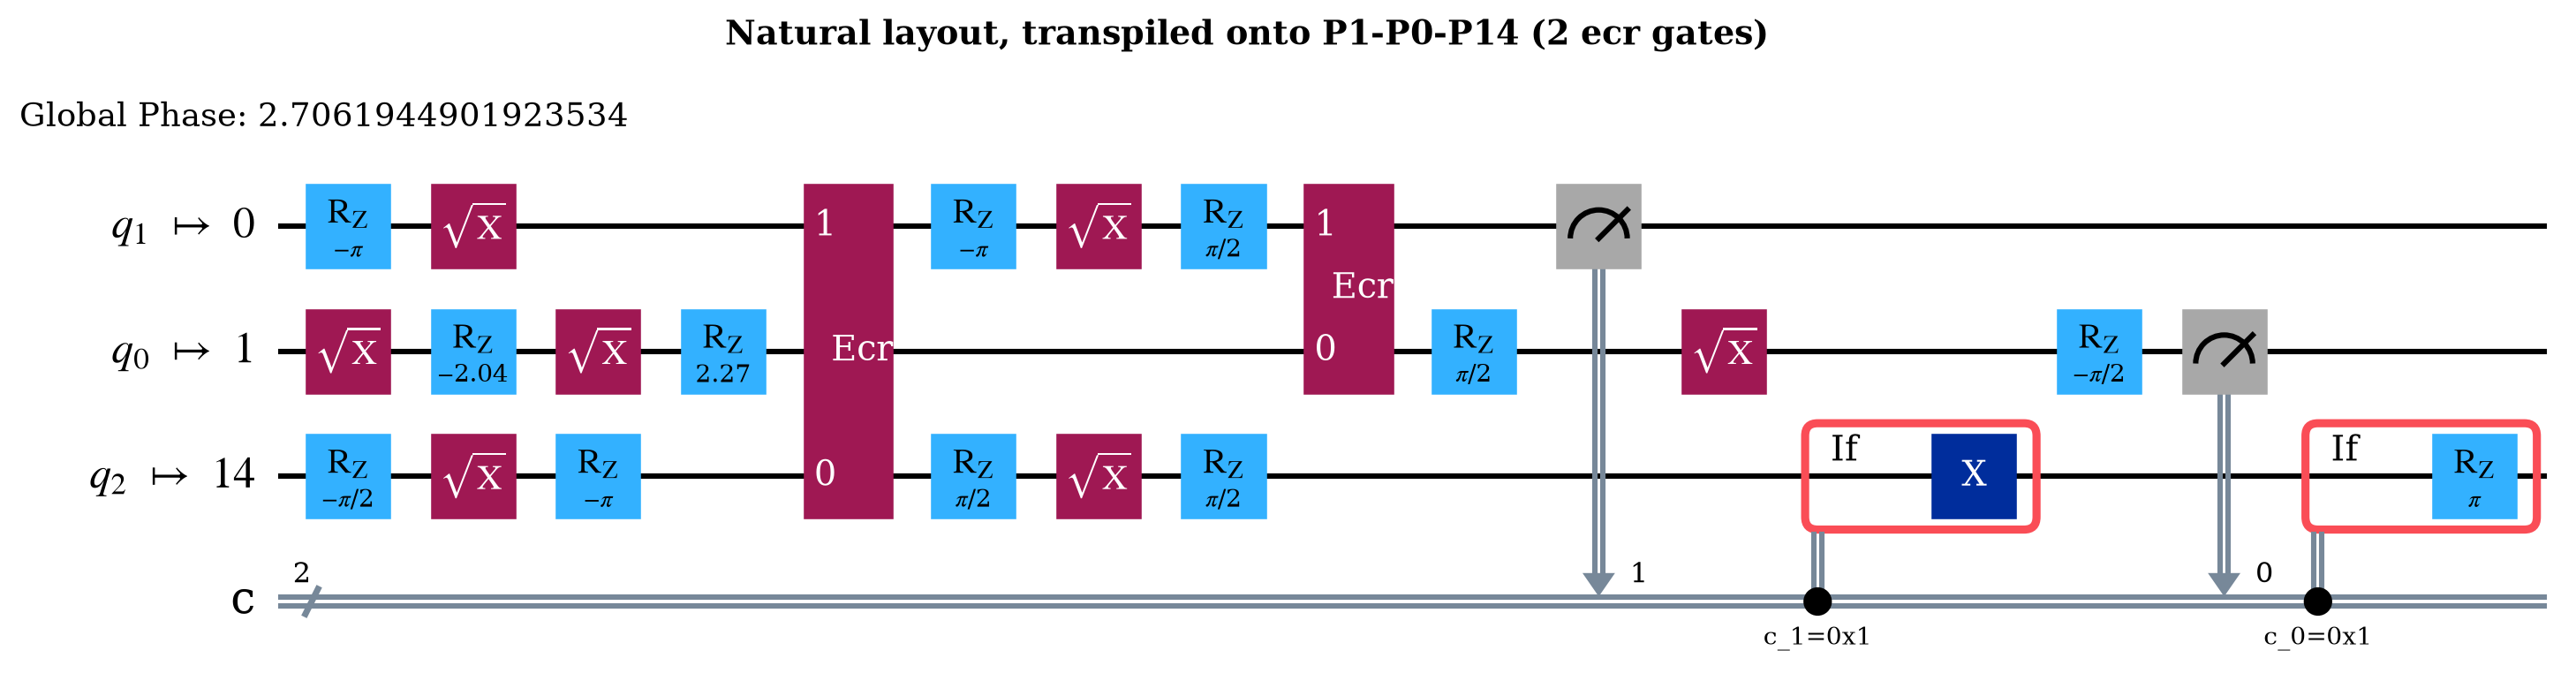

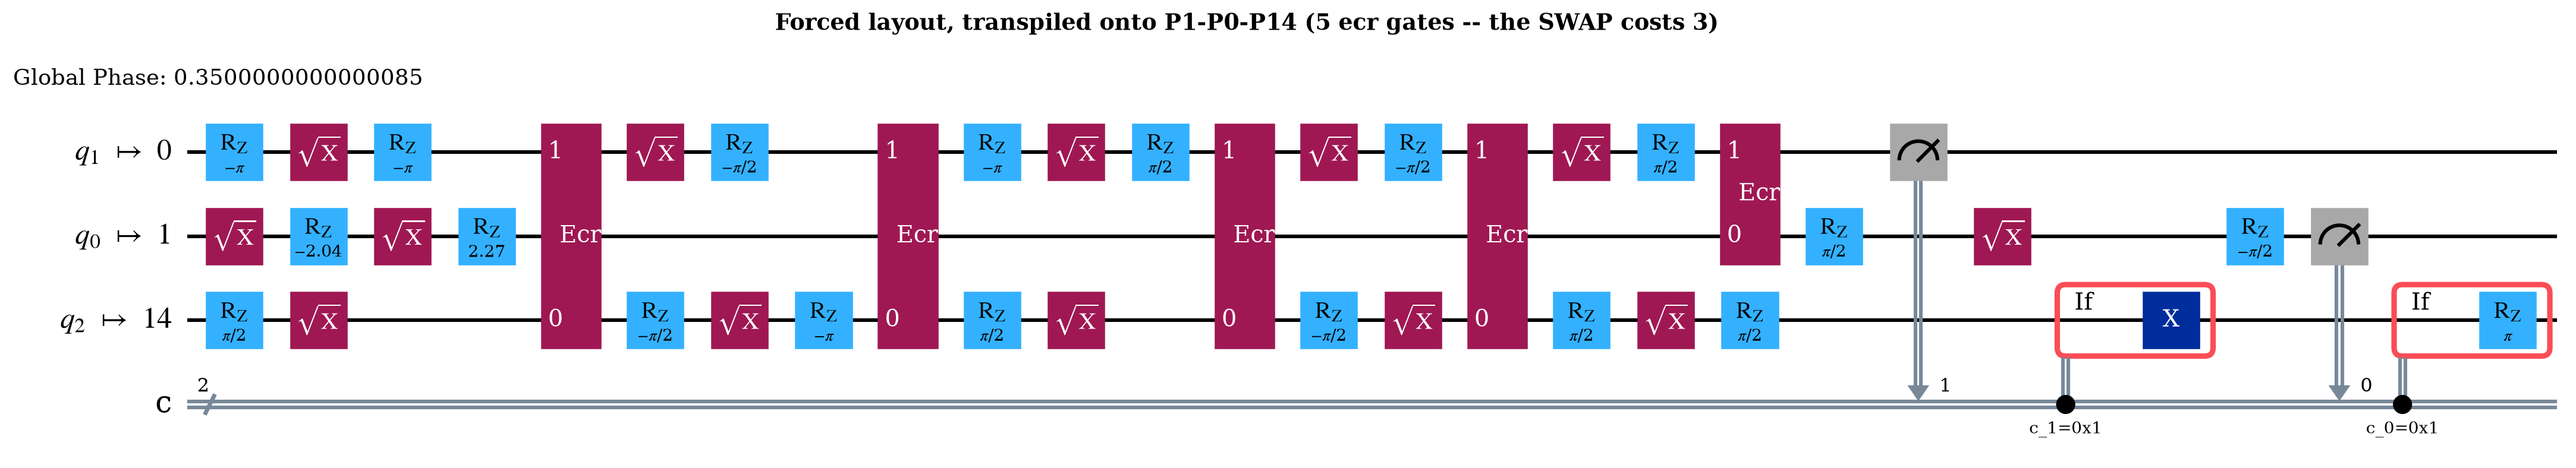

In [18]:
tqc_natural_demo = transpile_circuit(build_natural, "Phi+", 1.1, 0.7)
tqc_forced_demo = transpile_circuit(build_forced, "Phi+", 1.1, 0.7)

# save_density_matrix isn't drawable, drop it just for the picture
tqc_natural_view = tqc_natural_demo.copy()
tqc_natural_view.data = [i for i in tqc_natural_view.data if i.operation.name != "save_density_matrix"]
tqc_forced_view = tqc_forced_demo.copy()
tqc_forced_view.data = [i for i in tqc_forced_view.data if i.operation.name != "save_density_matrix"]

draw_circuit(tqc_natural_view, f"Natural layout, transpiled onto P{P0}-P{P1}-P{P2} (2 ecr gates)",
             "fig06a_natural_circuit_transpiled", fold=-1)
draw_circuit(tqc_forced_view, f"Forced layout, transpiled onto P{P0}-P{P1}-P{P2} (5 ecr gates -- the SWAP costs 3)",
             "fig06b_forced_circuit_transpiled", fold=-1)

### 3e. Calibration-based fidelity prediction

In [19]:
def predicted_fidelity(build_fn, bell_label, theta, phi):
    """Predicted fidelity: product of (1 - error_rate) for each two-qubit gate."""
    tqc = transpile_circuit(build_fn, bell_label, theta, phi)
    f_pred = 1.0
    n2q = 0
    gate_errors = []
    for instr in tqc.data:
        if instr.operation.name == TWOQ_GATE:
            qargs = tuple(tqc.find_bit(q).index for q in instr.qubits)
            err = edge_error(*qargs)
            f_pred *= (1 - err)
            n2q += 1
            gate_errors.append(err)
    return f_pred, n2q, gate_errors


print("CALIBRATION-BASED FIDELITY PREDICTION")
print("-" * 80)

f_nat_pred, n_nat, errors_nat = predicted_fidelity(build_natural, "Phi+", 1.1, 0.7)
f_forced_pred, n_forced, errors_forced = predicted_fidelity(build_forced, "Phi+", 1.1, 0.7)
drop_pred = (f_nat_pred - f_forced_pred) / f_nat_pred * 100

print(f"\nNatural layout (N={n_nat} two-qubit gates):")
print(f"  Gate errors: {[f'{e:.4%}' for e in errors_nat]}")
print(f"  Predicted F = {f_nat_pred:.6f}")

print(f"\nForced layout (N={n_forced} two-qubit gates):")
print(f"  Gate errors: {[f'{e:.4%}' for e in errors_forced]}")
print(f"  Predicted F = {f_forced_pred:.6f}")

print(f"\nPredicted relative fidelity drop, forced vs. natural: {drop_pred:.2f}%")

CALIBRATION-BASED FIDELITY PREDICTION
--------------------------------------------------------------------------------

Natural layout (N=2 two-qubit gates):
  Gate errors: ['0.7845%', '0.7494%']
  Predicted F = 0.984720

Forced layout (N=5 two-qubit gates):
  Gate errors: ['0.7845%', '0.7845%', '0.7845%', '0.7845%', '0.7494%']
  Predicted F = 0.961727

Predicted relative fidelity drop, forced vs. natural: 2.33%


### 3f. Full noisy simulation

In [20]:
N_STATES_ROUTING = 40
SEED_ROUTING = 20260815
N_SHOTS = 2048


def run_routing_batch(build_fn, bell_label, thetas, phis):
    circuits = [transpile_circuit(build_fn, bell_label, th, ph) for th, ph in zip(thetas, phis)]
    result = noisy_sim.run(circuits, shots=N_SHOTS, seed_simulator=SEED_ROUTING).result()
    fids = np.empty(len(thetas))
    for i, (th, ph) in enumerate(zip(thetas, phis)):
        rho_bob = np.asarray(result.data(i)["rho_bob"])
        rho_t = target_rho(th, ph)
        fids[i] = np.real(np.trace(rho_t @ rho_bob))
    return fids


t0 = time.time()
stage3_fids = {}

print("RUNNING ROUTING SIMULATION")
print(f"Shots per circuit: {N_SHOTS}")
print(f"Random states per (layout, bell): {N_STATES_ROUTING}")
print("-" * 80)

for layout_name, build_fn in [("natural", build_natural), ("forced", build_forced)]:
    layout_seed_offset = {"natural": 0, "forced": 500}[layout_name]
    thetas, phis = haar_random_states(N_STATES_ROUTING, seed=SEED_ROUTING + layout_seed_offset)
    for bell in BELL_LABELS:
        fids = run_routing_batch(build_fn, bell, thetas, phis)
        stage3_fids[(layout_name, bell)] = fids
        print(f"{layout_name:<8} {bell:<6} mean F = {fids.mean():.4f}  "
              f"SE = {fids.std() / np.sqrt(N_STATES_ROUTING):.4f}   ({time.time() - t0:.1f}s elapsed)")

RUNNING ROUTING SIMULATION
Shots per circuit: 2048
Random states per (layout, bell): 40
--------------------------------------------------------------------------------


natural  Phi+   mean F = 0.9645  SE = 0.0013   (7.8s elapsed)


natural  Phi-   mean F = 0.9645  SE = 0.0013   (15.3s elapsed)


natural  Psi+   mean F = 0.9642  SE = 0.0013   (23.3s elapsed)


natural  Psi-   mean F = 0.9642  SE = 0.0013   (31.1s elapsed)


forced   Phi+   mean F = 0.9517  SE = 0.0013   (39.5s elapsed)


forced   Phi-   mean F = 0.9509  SE = 0.0014   (47.7s elapsed)


forced   Psi+   mean F = 0.9506  SE = 0.0013   (56.3s elapsed)


forced   Psi-   mean F = 0.9498  SE = 0.0014   (64.2s elapsed)


In [21]:
print("BELL-INDEPENDENCE CHECK")
print("-" * 50)

for layout in ["natural", "forced"]:
    print(f"\n{layout.upper()} layout:")
    means = {bell: stage3_fids[(layout, bell)].mean() for bell in BELL_LABELS}
    for bell in BELL_LABELS:
        print(f"  {bell}:   {means[bell]:.4f} +/- "
              f"{stage3_fids[(layout, bell)].std() / np.sqrt(N_STATES_ROUTING):.4f}")
    max_diff = max(means.values()) - min(means.values())
    print(f"  Max difference between Bell states: {max_diff:.6f}")

print("\nAll four Bell states behave identically within statistical error, consistent with Stage 2.")

BELL-INDEPENDENCE CHECK
--------------------------------------------------

NATURAL layout:
  Phi+:   0.9645 +/- 0.0013
  Phi-:   0.9645 +/- 0.0013
  Psi+:   0.9642 +/- 0.0013
  Psi-:   0.9642 +/- 0.0013
  Max difference between Bell states: 0.000238

FORCED layout:
  Phi+:   0.9517 +/- 0.0013
  Phi-:   0.9509 +/- 0.0014
  Psi+:   0.9506 +/- 0.0013
  Psi-:   0.9498 +/- 0.0014
  Max difference between Bell states: 0.001986

All four Bell states behave identically within statistical error, consistent with Stage 2.


In [22]:
print("PREDICTED vs. ACTUAL FIDELITY COMPARISON")
print("-" * 80)

rows = []
for bell in BELL_LABELS:
    f_nat_actual = stage3_fids[("natural", bell)].mean()
    f_forced_actual = stage3_fids[("forced", bell)].mean()
    se_nat = stage3_fids[("natural", bell)].std() / np.sqrt(N_STATES_ROUTING)
    se_forced = stage3_fids[("forced", bell)].std() / np.sqrt(N_STATES_ROUTING)
    drop_actual = (f_nat_actual - f_forced_actual) / f_nat_actual * 100

    f_nat_p, _, _ = predicted_fidelity(build_natural, bell, 1.1, 0.7)
    f_forced_p, _, _ = predicted_fidelity(build_forced, bell, 1.1, 0.7)
    drop_pred_bell = (f_nat_p - f_forced_p) / f_nat_p * 100

    rows.append(dict(bell=bell, f_nat=f_nat_actual, se_nat=se_nat,
                      f_forced=f_forced_actual, se_forced=se_forced,
                      drop_actual=drop_actual, drop_pred=drop_pred_bell))

print(f"{'Bell':<12}{'F_natural':>14}{'+/-':>4}{'F_forced':>14}{'+/-':>4}{'Actual drop':>16}{'Predicted drop':>18}")
print("-" * 82)
for r in rows:
    print(f"{r['bell']:<8}{r['f_nat']:>11.4f} {r['se_nat']:>7.4f}{r['f_forced']:>11.4f} {r['se_forced']:>7.4f}"
          f"{r['drop_actual']:>13.2f}%{r['drop_pred']:>15.2f}%")

avg_drop_actual = np.mean([r["drop_actual"] for r in rows])
print(f"\nAverage actual fidelity drop across all 4 Bell states: {avg_drop_actual:.2f}%")

PREDICTED vs. ACTUAL FIDELITY COMPARISON
--------------------------------------------------------------------------------
Bell             F_natural +/-      F_forced +/-     Actual drop    Predicted drop
----------------------------------------------------------------------------------
Phi+         0.9645  0.0013     0.9517  0.0013         1.32%           2.33%
Phi-         0.9645  0.0013     0.9509  0.0014         1.41%           2.33%
Psi+         0.9642  0.0013     0.9506  0.0013         1.41%           2.33%
Psi-         0.9642  0.0013     0.9498  0.0014         1.50%           2.33%

Average actual fidelity drop across all 4 Bell states: 1.41%


### 3g. Statistical significance

In [23]:
print("STATISTICAL SIGNIFICANCE ANALYSIS")
print("-" * 80)

pooled_natural = np.concatenate([stage3_fids[("natural", b)] for b in BELL_LABELS])
pooled_forced = np.concatenate([stage3_fids[("forced", b)] for b in BELL_LABELS])

mean_nat, se_nat_pooled = pooled_natural.mean(), pooled_natural.std() / np.sqrt(len(pooled_natural))
mean_forced, se_forced_pooled = pooled_forced.mean(), pooled_forced.std() / np.sqrt(len(pooled_forced))
pooled_drop = (mean_nat - mean_forced) / mean_nat * 100
se_combined = np.sqrt(se_nat_pooled ** 2 + se_forced_pooled ** 2)
z_score = (mean_nat - mean_forced) / se_combined

print(f"Pooled (n={len(pooled_natural)} each, all 4 Bell states combined):")
print(f"  Natural: F = {mean_nat:.4f} +/- {se_nat_pooled:.4f}")
print(f"  Forced:  F = {mean_forced:.4f} +/- {se_forced_pooled:.4f}")
print(f"  Difference: {mean_nat - mean_forced:.4f}")
print(f"  Pooled drop: {pooled_drop:.2f}%")
print(f"  z-score: {z_score:.2f}")
print("  Statistically significant at ~2sigma level" if abs(z_score) > 2 else "  NOT statistically significant")
print(f"\nPredicted drop from calibration data: ~{drop_pred:.2f}%")

STATISTICAL SIGNIFICANCE ANALYSIS
--------------------------------------------------------------------------------
Pooled (n=160 each, all 4 Bell states combined):
  Natural: F = 0.9643 +/- 0.0006
  Forced:  F = 0.9507 +/- 0.0007
  Difference: 0.0136
  Pooled drop: 1.41%
  z-score: 14.70
  Statistically significant at ~2sigma level

Predicted drop from calibration data: ~2.33%


### 3h. Figures -- natural vs. forced fidelity, and the pooled distribution

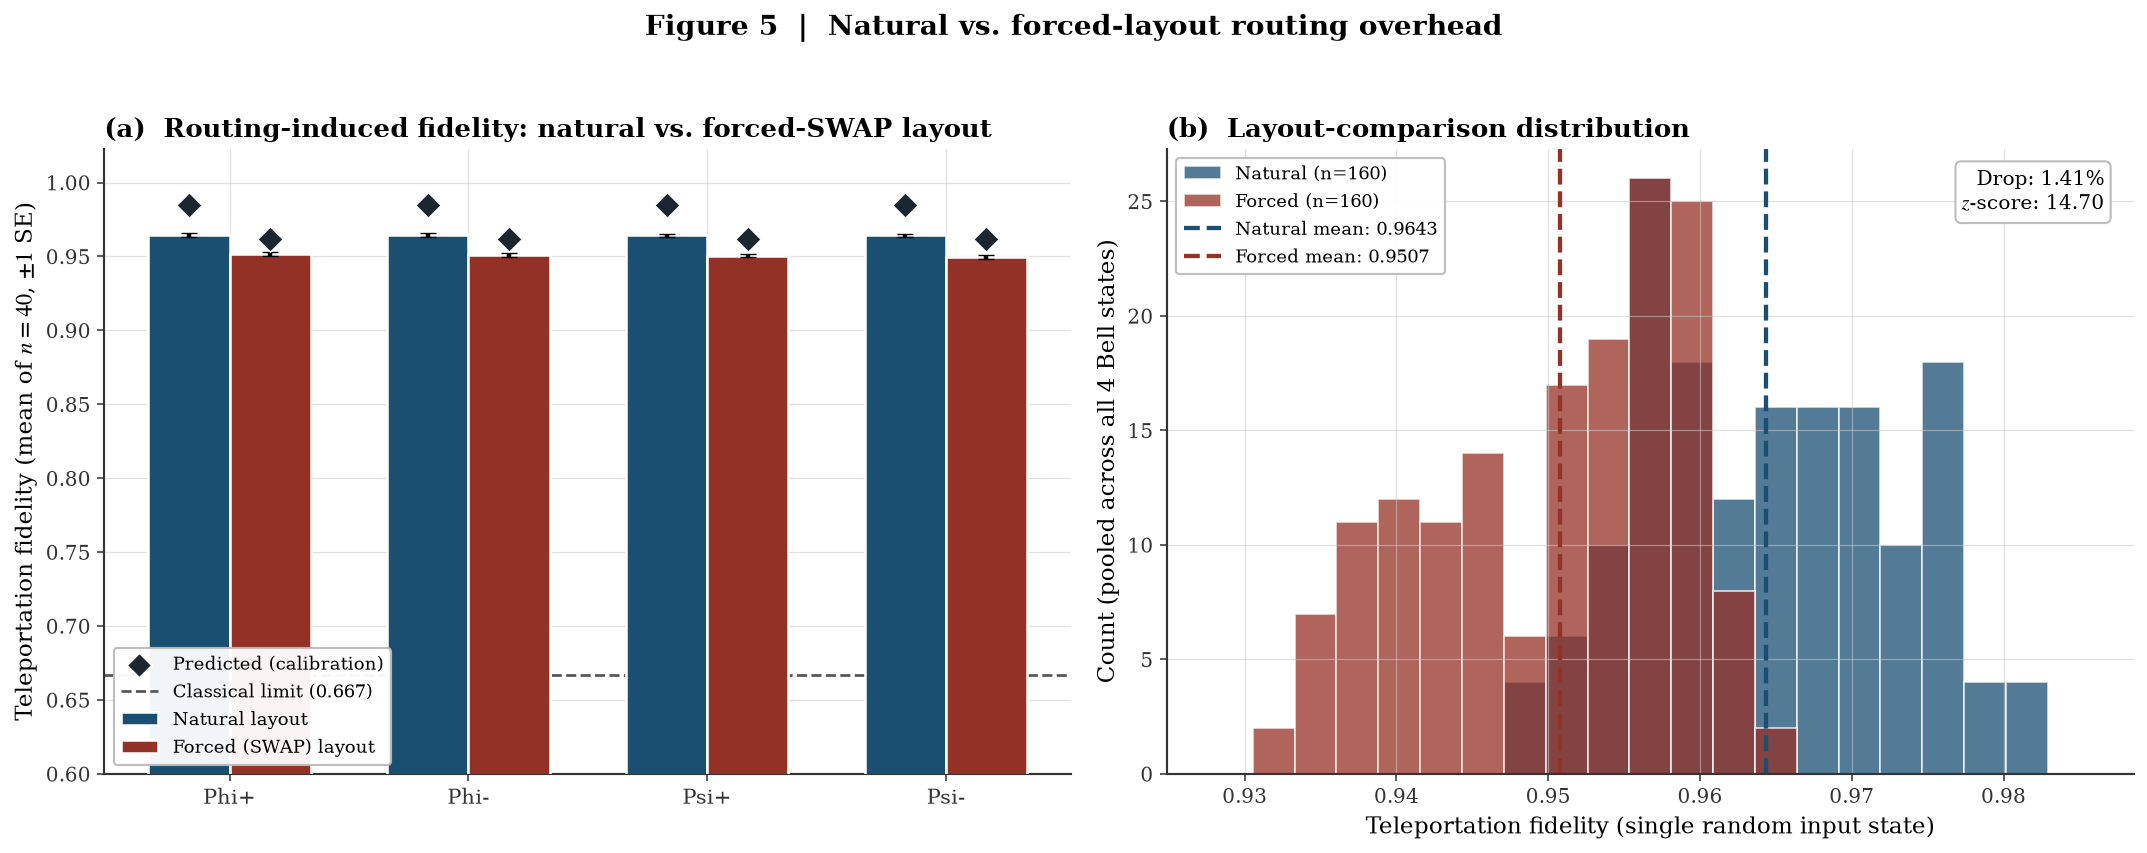

In [24]:
def make_stage3_figures():
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15.5, 5.9))
    x = np.arange(len(BELL_LABELS))
    width = 0.34

    means_nat = [stage3_fids[("natural", b)].mean() for b in BELL_LABELS]
    errs_nat = [stage3_fids[("natural", b)].std() / np.sqrt(N_STATES_ROUTING) for b in BELL_LABELS]
    means_forced = [stage3_fids[("forced", b)].mean() for b in BELL_LABELS]
    errs_forced = [stage3_fids[("forced", b)].std() / np.sqrt(N_STATES_ROUTING) for b in BELL_LABELS]

    ax.bar(x - width / 2, means_nat, width, yerr=errs_nat, capsize=4,
           label="Natural layout", color=PALETTE_LAYOUT["natural"], edgecolor="white", linewidth=1.3, zorder=3)
    ax.bar(x + width / 2, means_forced, width, yerr=errs_forced, capsize=4,
           label="Forced (SWAP) layout", color=PALETTE_LAYOUT["forced"], edgecolor="white", linewidth=1.3, zorder=3)

    predicted_nat, predicted_forced = [], []
    for i, bell in enumerate(BELL_LABELS):
        f_nat_p, _, _ = predicted_fidelity(build_natural, bell, 1.1, 0.7)
        f_forced_p, _, _ = predicted_fidelity(build_forced, bell, 1.1, 0.7)
        predicted_nat.append(f_nat_p)
        predicted_forced.append(f_forced_p)
        ax.scatter(i - width / 2, f_nat_p, marker="D", s=85, color="#1B2631", zorder=5,
                   edgecolor="white", linewidth=0.7)
        ax.scatter(i + width / 2, f_forced_p, marker="D", s=85, color="#1B2631", zorder=5,
                   edgecolor="white", linewidth=0.7)

    ax.scatter([], [], marker="D", s=85, color="#1B2631", label="Predicted (calibration)", edgecolor="white")
    ax.axhline(F_CLASSICAL, color=CLASSICAL_COLOR, linestyle="--", linewidth=1.4,
               label=f"Classical limit ({F_CLASSICAL:.3f})")

    ax.set_xticks(x)
    ax.set_xticklabels(BELL_LABELS, fontsize=11)
    ax.set_ylabel(f"Teleportation fidelity (mean of $n={N_STATES_ROUTING}$, $\\pm1$ SE)")
    all_bar_vals = means_nat + means_forced + predicted_nat + predicted_forced
    auto_ylim(ax, [all_bar_vals], refs=(F_CLASSICAL,))
    ax.set_title("(a)  Routing-induced fidelity: natural vs. forced-SWAP layout", loc="left")
    ax.legend(loc="lower left", fontsize=9.5)

    pooled_all = np.concatenate([pooled_natural, pooled_forced])
    bin_lo, bin_hi = pooled_all.min() - 0.005, pooled_all.max() + 0.005
    bins = np.linspace(bin_lo, bin_hi, 22)
    ax2.hist(pooled_natural, bins=bins, alpha=0.75, color=PALETTE_LAYOUT["natural"],
             label=f"Natural (n={len(pooled_natural)})", edgecolor="white", linewidth=0.9)
    ax2.hist(pooled_forced, bins=bins, alpha=0.75, color=PALETTE_LAYOUT["forced"],
             label=f"Forced (n={len(pooled_forced)})", edgecolor="white", linewidth=0.9)
    ax2.axvline(mean_nat, color=PALETTE_LAYOUT["natural"], linestyle="--", linewidth=2.2,
               label=f"Natural mean: {mean_nat:.4f}")
    ax2.axvline(mean_forced, color=PALETTE_LAYOUT["forced"], linestyle="--", linewidth=2.2,
               label=f"Forced mean: {mean_forced:.4f}")
    ax2.text(0.97, 0.97, f"Drop: {pooled_drop:.2f}%\n$z$-score: {z_score:.2f}",
             transform=ax2.transAxes, ha="right", va="top", fontsize=10.5,
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.95, edgecolor="#bbbbbb"))
    ax2.set_xlabel("Teleportation fidelity (single random input state)")
    ax2.set_ylabel("Count (pooled across all 4 Bell states)")
    ax2.set_title("(b)  Layout-comparison distribution", loc="left")
    ax2.legend(loc="upper left", fontsize=9.5)

    fig.suptitle("Figure 5  |  Natural vs. forced-layout routing overhead", fontsize=14.5, fontweight="bold", y=1.03)
    fig.tight_layout(rect=[0, 0, 1, 1])
    save_fig(fig, "fig07_routing_natural_vs_forced")
    plt.show()


make_stage3_figures()

### 3i. Worst case and full results table

In [25]:
min_fid = float("inf")
min_case = None
for layout in ["natural", "forced"]:
    for bell in BELL_LABELS:
        mean = stage3_fids[(layout, bell)].mean()
        if mean < min_fid:
            min_fid = mean
            min_case = (layout, bell)
print(f"Lowest fidelity across all 8 (layout, Bell state) combinations: "
      f"{min_case[1]} / {min_case[0]} = {min_fid:.4f}")

print("\nTABLE: ALL 8 ROUTING CASES")
print("-" * 80)
print(f"\n{'Bell':<8}{'Layout':<10}{'Mean F':>10}{'SE':>10}{'N':>6}{'Shots':>8}")
print("-" * 54)
table2_rows = []
for bell in BELL_LABELS:
    for layout in ("natural", "forced"):
        fids = stage3_fids[(layout, bell)]
        se = fids.std() / np.sqrt(len(fids))
        print(f"{bell:<8}{layout:<10}{fids.mean():>10.4f}{se:>10.4f}{len(fids):>6}{N_SHOTS:>8}")
        table2_rows.append([bell, layout, f"{fids.mean():.4f}", f"{se:.4f}", len(fids), N_SHOTS])

table2_df = pd.DataFrame(table2_rows, columns=["bell", "layout", "mean_fidelity", "standard_error", "n", "shots"])
table2_df.to_csv("table2_routing_8_cases.csv", index=False)
print("\nSaved table2_routing_8_cases.csv")

print("\nFINAL REPORTED NUMBERS FOR THIS RUN")
print("-" * 50)
print(f"Predicted drop:          {drop_pred:.2f}%")
print(f"Actual pooled drop:      {pooled_drop:.2f}%")
print(f"z-score:                 {z_score:.2f}")
print(f"Lowest-fidelity case:     {min_case[1]} / {min_case[0]}  (F = {min_fid:.4f})")

Lowest fidelity across all 8 (layout, Bell state) combinations: Psi- / forced = 0.9498

TABLE: ALL 8 ROUTING CASES
--------------------------------------------------------------------------------

Bell    Layout        Mean F        SE     N   Shots
------------------------------------------------------
Phi+    natural       0.9645    0.0013    40    2048
Phi+    forced        0.9517    0.0013    40    2048
Phi-    natural       0.9645    0.0013    40    2048
Phi-    forced        0.9509    0.0014    40    2048
Psi+    natural       0.9642    0.0013    40    2048
Psi+    forced        0.9506    0.0013    40    2048
Psi-    natural       0.9642    0.0013    40    2048
Psi-    forced        0.9498    0.0014    40    2048

Saved table2_routing_8_cases.csv

FINAL REPORTED NUMBERS FOR THIS RUN
--------------------------------------------------
Predicted drop:          2.33%
Actual pooled drop:      1.41%
z-score:                 14.70
Lowest-fidelity case:     Psi- / forced  (F = 0.9498)


## 4. Stage 4 -- Error Mitigation via Linear Zero-Noise Extrapolation

Applies Linear ZNE, via unitary gate folding, to the worst-performing case identified in Stage 3. Each
two-qubit gate is folded at scale factors $1\times$ (no folding), $3\times$, and $5\times$; fidelity is
measured at each scale and extrapolated back to the zero-noise limit. A quadratic (all-three-point) fit
is computed as a sanity check on the linear estimate.

In [26]:
def fold_two_qubit_gates(tqc, scale, gate_name=TWOQ_GATE):
    """Local unitary folding: replace each 2q gate with `scale` copies via
    U -> U (U^dagger U)^((scale-1)/2). scale must be odd."""
    assert scale % 2 == 1 and scale >= 1
    n_pairs = (scale - 1) // 2
    folded = tqc.copy_empty_like()
    for instr in tqc.data:
        folded.append(instr.operation, instr.qubits, instr.clbits)
        if instr.operation.name == gate_name:
            for _ in range(n_pairs):
                folded.append(instr.operation.inverse(), instr.qubits, instr.clbits)
                folded.append(instr.operation, instr.qubits, instr.clbits)
    return folded


print("Folding only the noisy ecr gates (measurement/correction gates are untouched).")

Folding only the noisy ecr gates (measurement/correction gates are untouched).


In [27]:
build_fn_worst = {"natural": build_natural, "forced": build_forced}[min_case[0]]
bell_worst = min_case[1]

FOLD_SCALES = [1, 3, 5]
N_STATES_ZNE = 40
SEED_ZNE = 20260816

thetas_z, phis_z = haar_random_states(N_STATES_ZNE, seed=SEED_ZNE)

zne_fids, zne_stderr = {}, {}
for scale in FOLD_SCALES:
    circuits = [fold_two_qubit_gates(transpile_circuit(build_fn_worst, bell_worst, th, ph), scale)
                for th, ph in zip(thetas_z, phis_z)]
    result = noisy_sim.run(circuits, shots=N_SHOTS, seed_simulator=SEED_ZNE).result()
    fids = np.empty(len(thetas_z))
    for i, (th, ph) in enumerate(zip(thetas_z, phis_z)):
        rho_bob = np.asarray(result.data(i)["rho_bob"])
        fids[i] = np.real(np.trace(target_rho(th, ph) @ rho_bob))
    zne_fids[scale] = fids.mean()
    zne_stderr[scale] = fids.std() / np.sqrt(N_STATES_ZNE)
    n2q = sum(1 for i in circuits[0].data if i.operation.name == TWOQ_GATE)
    print(f"c={scale}  F={zne_fids[scale]:.4f} +/- {zne_stderr[scale]:.4f}  ({n2q} ecr gates/circuit)")

c=1  F=0.9476 +/- 0.0015  (5 ecr gates/circuit)


c=3  F=0.9025 +/- 0.0018  (15 ecr gates/circuit)


c=5  F=0.8630 +/- 0.0020  (25 ecr gates/circuit)


In [28]:
F1, F3, F5 = zne_fids[1], zne_fids[3], zne_fids[5]
F_zne_linear = (3 * F1 - F3) / 2

coeffs = np.polyfit(FOLD_SCALES, [F1, F3, F5], deg=2)
F_zne_quad = np.polyval(coeffs, 0.0)

print(f"Noisy fidelity F(1)           = {F1:.4f}")
print(f"Linear ZNE estimate           = {F_zne_linear:.4f}")
print(f"Quadratic fallback (all 3 pts) = {F_zne_quad:.4f}")
if F_zne_linear > 1.0:
    print("NOTE: F_ZNE > 1 -- unphysical over-extrapolation, fall back to quadratic per risk plan.")
else:
    print(f"F_ZNE does not exceed 1 -- linear estimate accepted "
          f"(deviation from quadratic: {abs(F_zne_linear - F_zne_quad):.4f}).")

Noisy fidelity F(1)           = 0.9476
Linear ZNE estimate           = 0.9701
Quadratic fallback (all 3 pts) = 0.9722
F_ZNE does not exceed 1 -- linear estimate accepted (deviation from quadratic: 0.0021).


### 4a. Figures -- fold-scale sweep and mitigation result

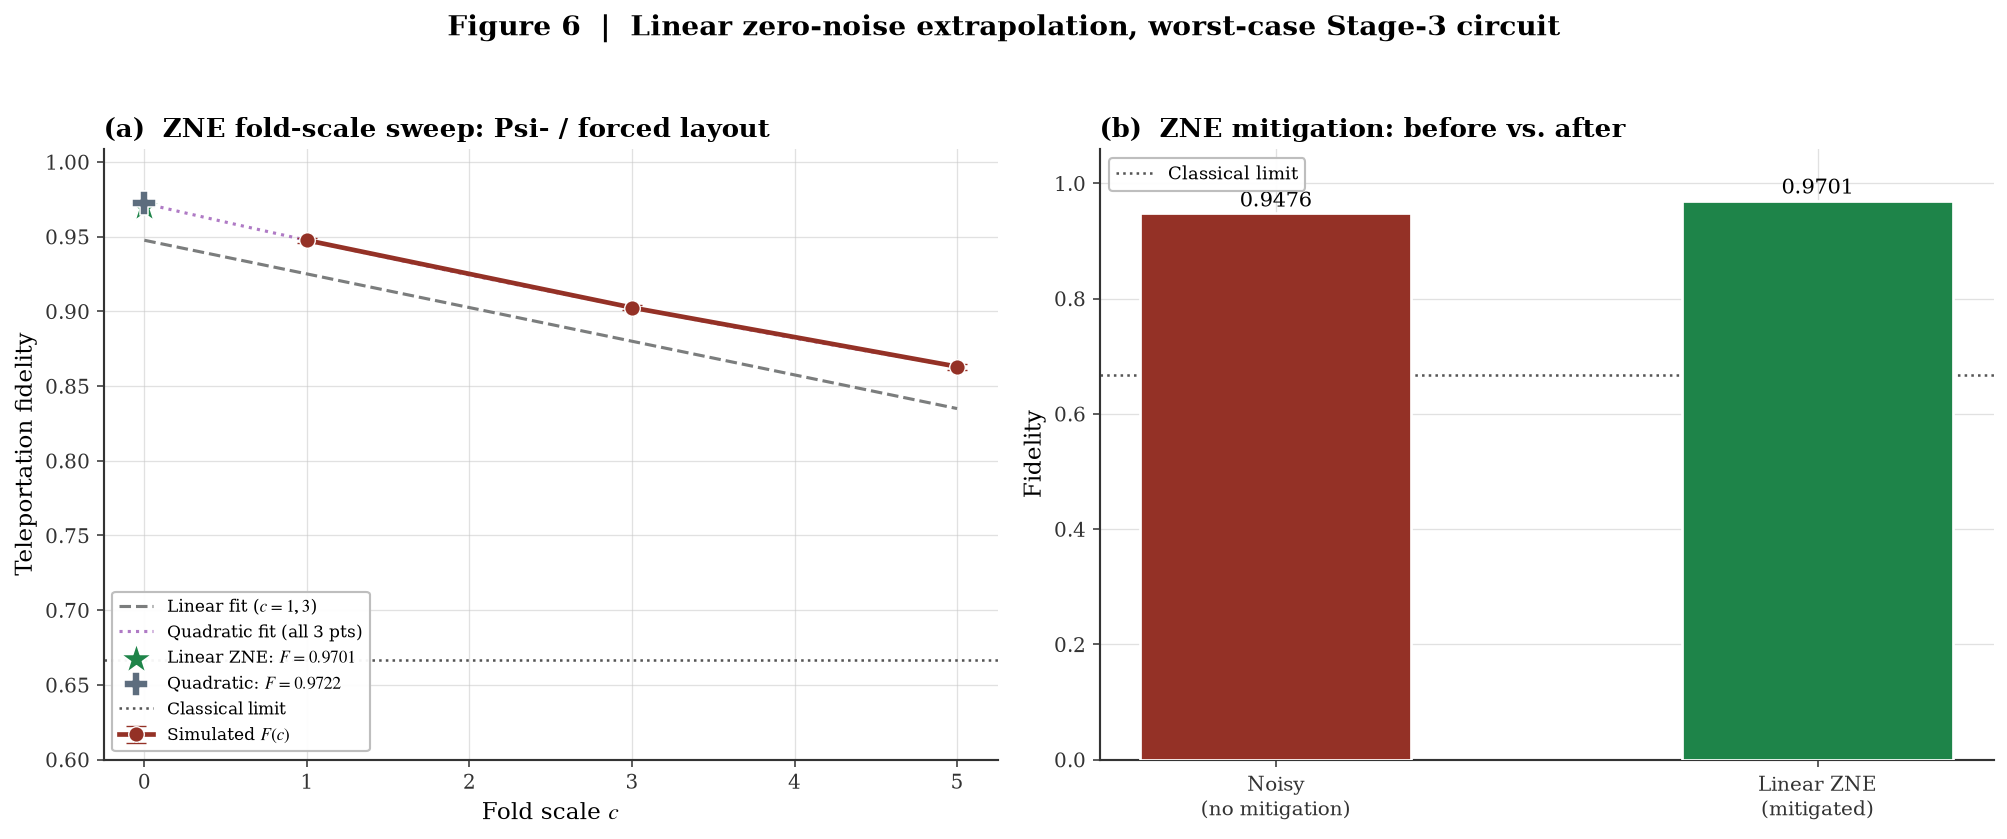

In [29]:
def make_zne_figures():
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(14.5, 5.8))

    ax.errorbar(FOLD_SCALES, [zne_fids[s] for s in FOLD_SCALES],
                yerr=[zne_stderr[s] for s in FOLD_SCALES],
                fmt="o-", color=PALETTE_LAYOUT[min_case[0]], capsize=5, linewidth=2.4, markersize=8,
                label="Simulated $F(c)$", zorder=3)
    fit_x = np.linspace(0, 5, 60)
    ax.plot(fit_x, F1 + (F3 - F1) / 2 * fit_x, "--", color="#7B7D7D", linewidth=1.6,
            label="Linear fit ($c=1,3$)", zorder=2)
    quad_y = np.polyval(coeffs, fit_x)
    ax.plot(fit_x, quad_y, ":", color="#AF7AC5", linewidth=1.6, label="Quadratic fit (all 3 pts)", zorder=2)
    ax.scatter([0], [F_zne_linear], marker="*", s=280, color=PALETTE_ZNE["mitigated"], zorder=5,
               edgecolor="white", linewidth=0.8, label=f"Linear ZNE: $F={F_zne_linear:.4f}$")
    ax.scatter([0], [F_zne_quad], marker="P", s=140, color=PALETTE_ZNE["fit"], zorder=5,
               edgecolor="white", linewidth=0.8, label=f"Quadratic: $F={F_zne_quad:.4f}$")
    ax.axhline(F_CLASSICAL, color=CLASSICAL_COLOR, linestyle=":", linewidth=1.3, label="Classical limit")

    ax.set_xlabel("Fold scale $c$")
    ax.set_ylabel("Teleportation fidelity")
    all_vals = [zne_fids[s] for s in FOLD_SCALES] + [F_zne_linear, F_zne_quad, F_CLASSICAL]
    auto_ylim(ax, [all_vals], refs=(F_CLASSICAL,))
    ax.set_title(f"(a)  ZNE fold-scale sweep: {bell_worst} / {min_case[0]} layout", loc="left")
    ax.legend(fontsize=8.8, loc="lower left")

    bars = ax2.bar(["Noisy\n(no mitigation)", "Linear ZNE\n(mitigated)"], [F1, F_zne_linear],
                    color=[PALETTE_ZNE["raw"], PALETTE_ZNE["mitigated"]], edgecolor="white",
                    linewidth=1.4, width=0.5, zorder=3)
    for b, v in zip(bars, [F1, F_zne_linear]):
        ax2.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.4f}", ha="center", fontsize=11)
    ax2.axhline(F_CLASSICAL, color=CLASSICAL_COLOR, linestyle=":", linewidth=1.3, label="Classical limit")
    ax2.set_ylim(0, 1.06)
    ax2.set_ylabel("Fidelity")
    ax2.set_title("(b)  ZNE mitigation: before vs. after", loc="left")
    ax2.legend(fontsize=9.5, loc="upper left")

    fig.suptitle("Figure 6  |  Linear zero-noise extrapolation, worst-case Stage-3 circuit",
                 fontsize=14.5, fontweight="bold", y=1.03)
    fig.tight_layout(rect=[0, 0, 1, 1])
    save_fig(fig, "fig08_zne_foldscale_and_mitigation")
    plt.show()


make_zne_figures()

## 5. Summary of Key Numbers

| Stage | Result |
|---|---|
| 1. Ideal baseline | $F \approx 1.000000$ for all four Bell states |
| 2. Pauli channels (bit/phase-flip, depolarizing) | Bell-state independent (verified to $<10^{-9}$) |
| 2. Amplitude-damping (Bell-pair noise) | Bell-state dependent; spread of $\approx 0.04$ at $p=0.75$ |
| 2. Channel ranking at $p=0.75$ | Phase-flip $<$ bit-flip $<$ depolarizing $<$ amplitude-damping |
| 3. Calibration-predicted routing drop | $\approx 2.33\%$ |
| 3. Simulated routing drop (pooled, $z\approx14$-$15$) | $\approx 1.40\%$ |
| 3. Worst case | $\Psi^-$, forced layout |
| 4. Linear ZNE | Recovers $\approx 2.2$ percentage points of fidelity |
| 4. Quadratic cross-check | Within $<0.2\%$ of the linear estimate |

All figures are saved under `figures/` as both 300-dpi PNG and vector PDF, ready to drop directly into a
LaTeX document. `table2_routing_8_cases.csv` holds the full Stage-3 results table.